In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report


In [2]:
df = pd.read_csv("C:/Users/anmnu/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/telco.csv")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn
['No' 'Yes']


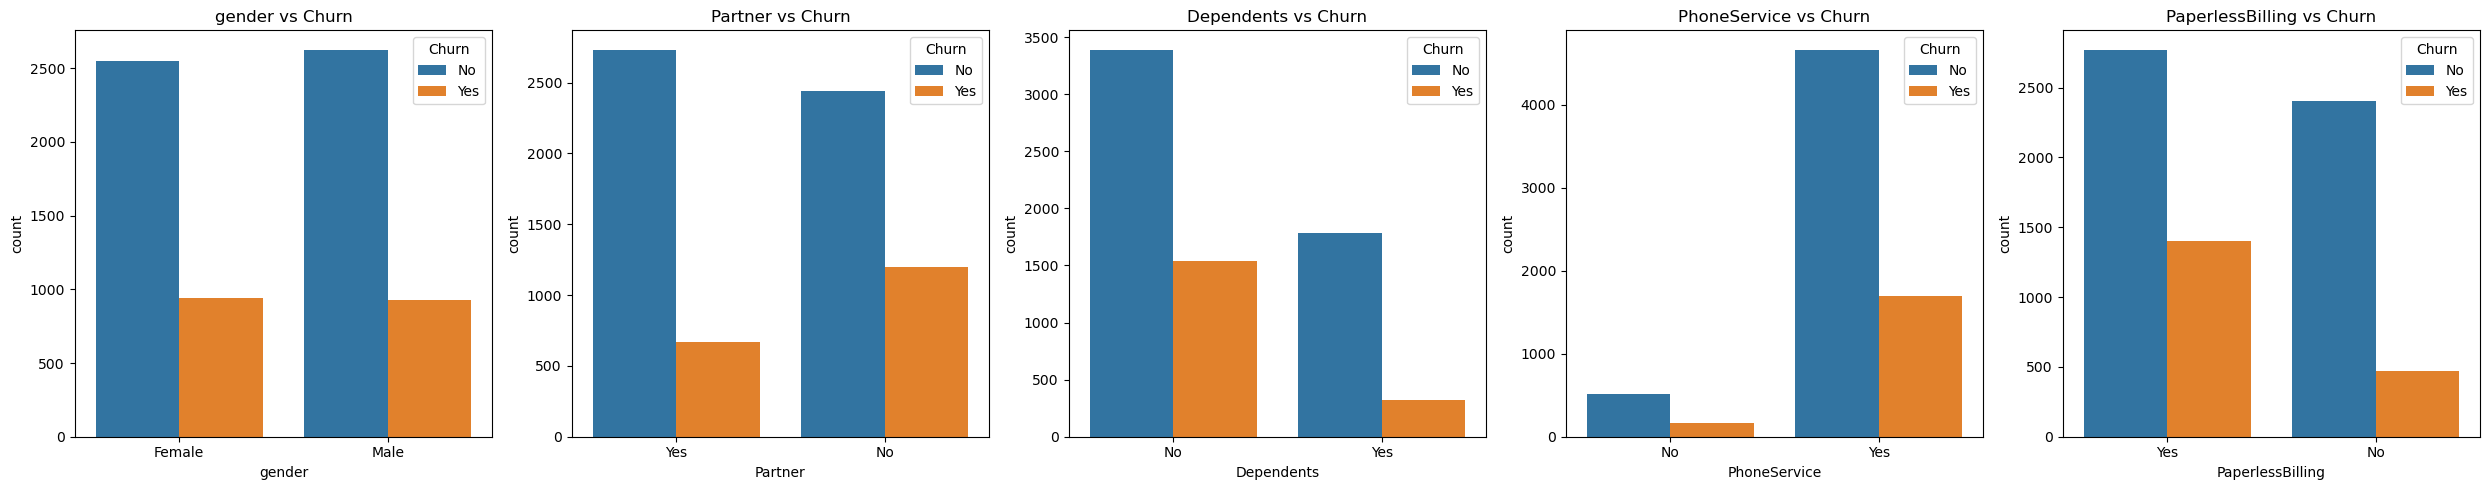

In [14]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

fig, axes = plt.subplots(1, 5, figsize=(25,5))

for col, ax in zip(binary_cols, axes.flatten()):
    
    sns.countplot(
        x=col,
        hue='Churn',
        data=df,
        ax=ax
    )
    
    ax.set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

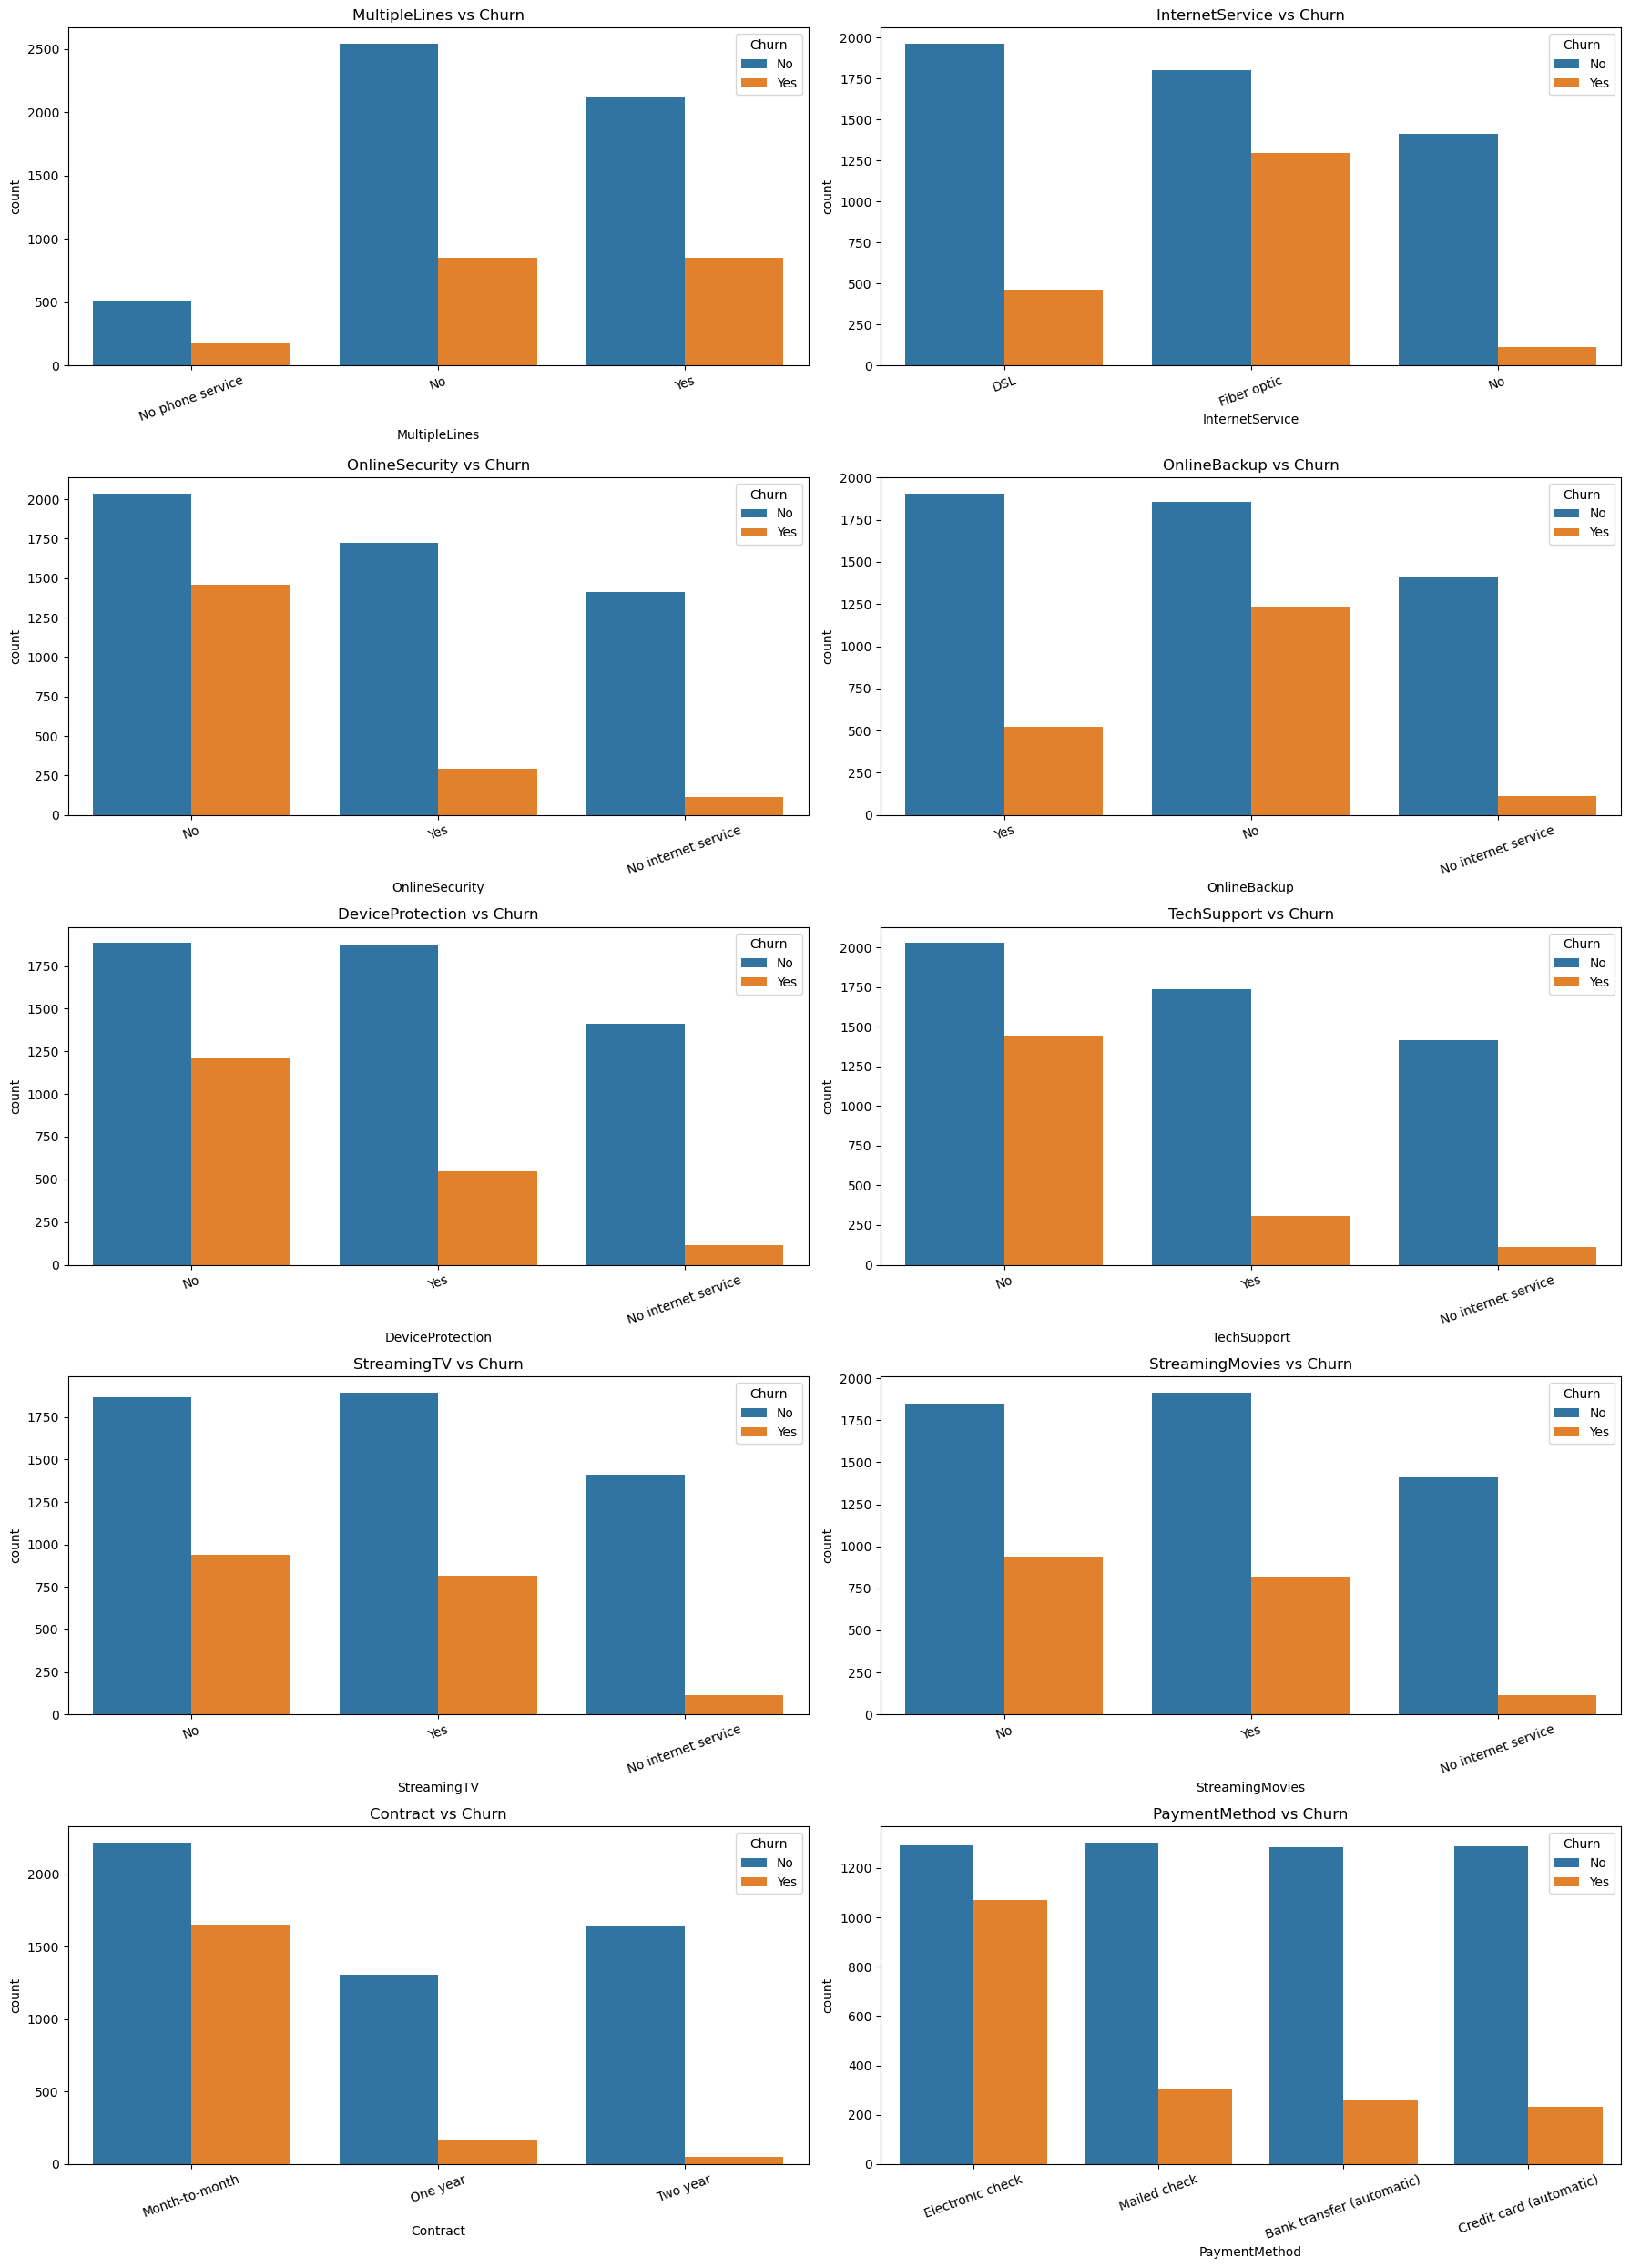

In [15]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

fig, axes = plt.subplots(5, 2, figsize=(18,25))

for col, ax in zip(multi_cols, axes.flatten()):
    
    sns.countplot(
        x=col,
        hue='Churn',
        data=df,
        ax=ax
    )
    
    ax.set_title(f'{col} vs Churn')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Drop customer ID, irrelevant

In [16]:
df.drop('customerID', axis=1, inplace=True)

### Converting the total charges to float

In [17]:
# Total Charges is supposed to be numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### Binary encoding, yes/no, 1/0

In [18]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [19]:
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
# female 1
# male 0

In [20]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.50,0
7039,1,0,1,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90,0
7040,1,0,1,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,0,1,1,0,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.60,1


### One-hot encode multi-category columns 

In [21]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]



# Important, first we want to visualize and so we keep the first rows 

In [22]:
# full dummy encoding
df_full = pd.get_dummies(df, columns=multi_cols, drop_first = False)

In [23]:
df_full

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,False,False,True,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,False,False,True
7039,1,0,1,1,72,1,1,103.20,7362.90,0,False,False,True,False,True,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True,False,True,False,False,True,False,False
7040,1,0,1,1,11,0,1,29.60,346.45,0,False,True,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
7041,0,1,1,0,4,1,1,74.40,306.60,1,False,False,True,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True


In [24]:
bool_cols = df_full.select_dtypes(include='bool').columns
df_full[bool_cols] = df_full[bool_cols].astype(int)

In [25]:
df_full

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1
7039,1,0,1,1,72,1,1,103.20,7362.90,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0
7040,1,0,1,1,11,0,1,29.60,346.45,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,1,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1


In [26]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7032 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         7043 no

In [27]:
df_full.isna().sum()

gender                                      0
SeniorCitizen                               0
Partner                                     0
Dependents                                  0
tenure                                      0
PhoneService                                0
PaperlessBilling                            0
MonthlyCharges                              0
TotalCharges                               11
Churn                                       0
MultipleLines_No                            0
MultipleLines_No phone service              0
MultipleLines_Yes                           0
InternetService_DSL                         0
InternetService_Fiber optic                 0
InternetService_No                          0
OnlineSecurity_No                           0
OnlineSecurity_No internet service          0
OnlineSecurity_Yes                          0
OnlineBackup_No                             0
OnlineBackup_No internet service            0
OnlineBackup_Yes                  

In [28]:
df_full.dropna(inplace=True)
df_full.isna().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
OnlineSecurity_No                          0
OnlineSecurity_No internet service         0
OnlineSecurity_Yes                         0
OnlineBackup_No                            0
OnlineBackup_No internet service           0
OnlineBackup_Yes                           0
DeviceProt

In [29]:
# reduced dummy encoding 
df_drop = pd.get_dummies(df, columns=multi_cols, drop_first = True)

In [30]:
df_drop

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,True,True,False,False,False,True
7039,1,0,1,1,72,1,1,103.20,7362.90,0,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,True,False,True,False,False
7040,1,0,1,1,11,0,1,29.60,346.45,0,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
7041,0,1,1,0,4,1,1,74.40,306.60,1,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [31]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [32]:
bool_cols = df_drop.select_dtypes(include='bool').columns
df_drop[bool_cols] = df_drop[bool_cols].astype(int)

In [33]:
df_drop

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,0,0,1
7039,1,0,1,1,72,1,1,103.20,7362.90,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,0,0
7040,1,0,1,1,11,0,1,29.60,346.45,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [34]:
df_drop.isna().sum()

gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service 

In [35]:
df_drop.dropna(inplace=True)
df_drop.isna().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

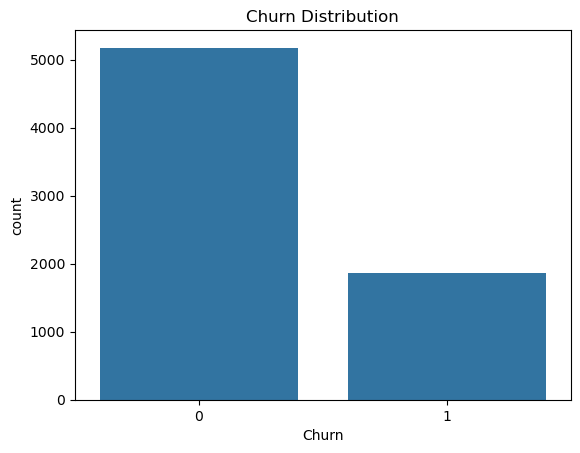

In [ ]:
sns.countplot(x='Churn', data=df)

plt.title('Churn Distribution')
plt.show()

# 1 - Churn
# 0 - No churn 

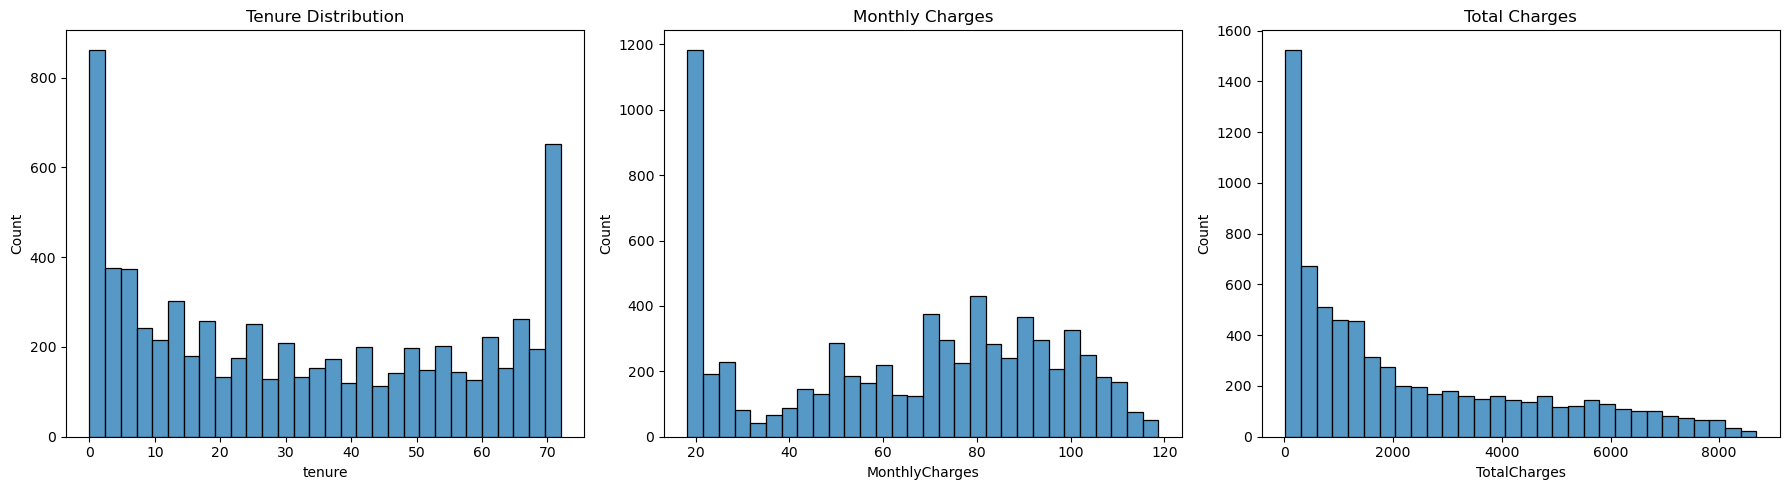

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['tenure'], bins=30, ax=axes[0])
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1])
axes[1].set_title('Monthly Charges')

sns.histplot(df['TotalCharges'], bins=30, ax=axes[2])
axes[2].set_title('Total Charges')

plt.tight_layout()
plt.show()

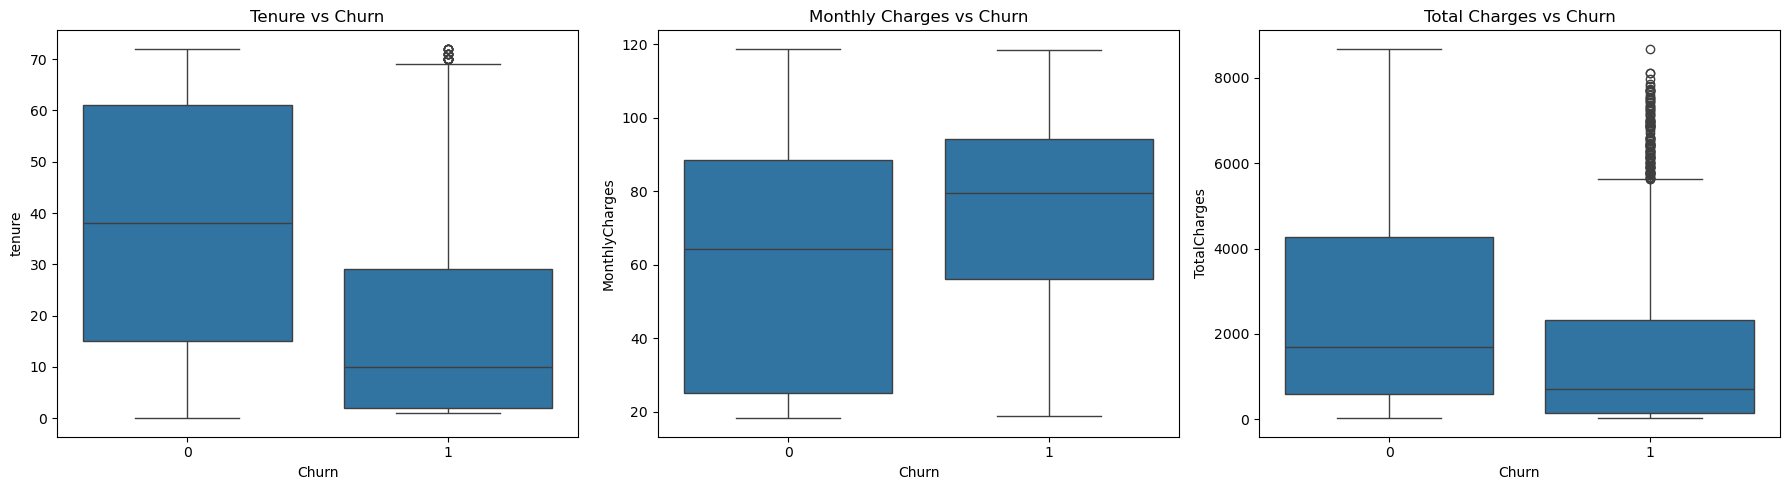

In [58]:

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
axes[0].set_title('Tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2])
axes[2].set_title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

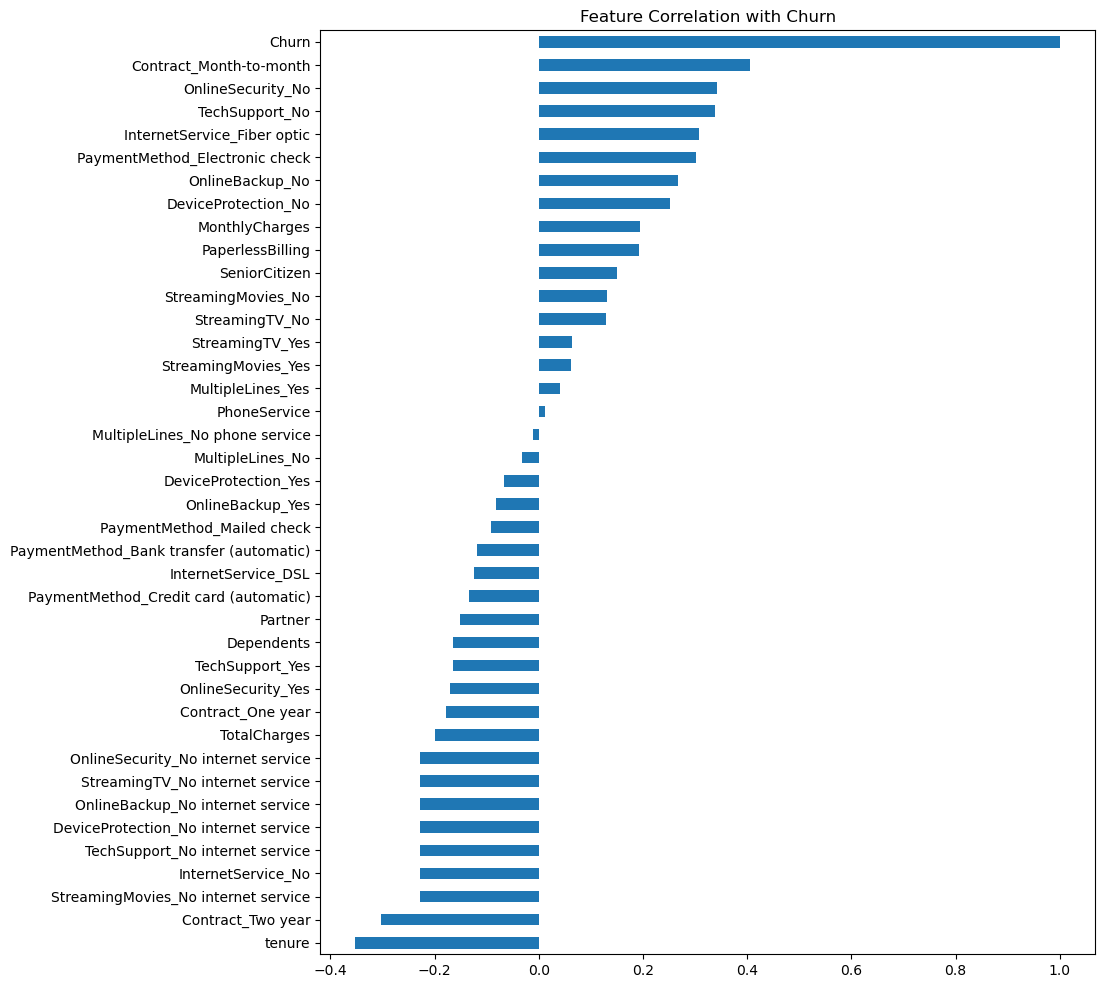

In [59]:
corr = df.corr(numeric_only=True)['Churn'].sort_values()

plt.figure(figsize=(10,12))

corr.plot(kind='barh')

plt.title('Feature Correlation with Churn')

plt.show()

# After data cleaning and one hot encoding
## Two dataframes
* df_full: with encoding, keeping all the encoding, full dummies
* df_drop: drop first, keeping only 2 for encoding

In [98]:
df_full

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1
7039,1,0,1,1,72,1,1,103.20,7362.90,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0
7040,1,0,1,1,11,0,1,29.60,346.45,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,1,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1


In [99]:
print(df_full.shape)

(7032, 41)


In [100]:
df_drop

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,0,0,1
7039,1,0,1,1,72,1,1,103.20,7362.90,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,0,0
7040,1,0,1,1,11,0,1,29.60,346.45,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [101]:
print(df_drop.shape)

(7032, 31)


## Baseline model 

### df_full

In [43]:
X_full = df_full.drop('Churn', axis = 1)
y_full = df_full['Churn']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size = 0.2, random_state = 42, stratify= y_full)

### KNN

In [146]:
from sklearn.neighbors import KNeighborsClassifier

In [147]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)


# =========================
# KNN MODEL
# =========================

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski'
)


# Train model

knn_model.fit(X_train_scaled, y_train_full)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = knn_model.predict(X_train_scaled)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_full, y_train_pred))

print()

print(classification_report(
    y_train_full,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = knn_model.predict(X_test_scaled)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_full, y_test_pred))

print()

print(classification_report(
    y_test_full,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = knn_model.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test_full, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_full, y_test_pred)

print("Confusion Matrix:")
print(cm)

TRAINING RESULTS

Accuracy: 0.8380444444444445

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4130
           1       0.72      0.65      0.68      1495

    accuracy                           0.84      5625
   macro avg       0.80      0.78      0.79      5625
weighted avg       0.83      0.84      0.84      5625

TESTING RESULTS

Accuracy: 0.7434257285003554

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1033
           1       0.52      0.52      0.52       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407

ROC-AUC Score: 0.769415440205828
Confusion Matrix:
[[850 183]
 [178 196]]


### LogisticRegression

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_full)

X_test_scaled = scaler.transform(X_test_full)


# =========================
# LOGISTIC REGRESSION MODEL
# =========================

model = LogisticRegression(max_iter=1000)

# Train model

model.fit(X_train_scaled, y_train_full)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = model.predict(X_train_scaled)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_full, y_train_pred))

print()

print(classification_report(
    y_train_full,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = model.predict(X_test_scaled)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_full, y_test_pred))

print()

print(classification_report(
    y_test_full,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = model.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test_full, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_full, y_test_pred)

print("Confusion Matrix:")
print(cm)

TRAINING RESULTS

Accuracy: 0.8044444444444444

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4130
           1       0.66      0.55      0.60      1495

    accuracy                           0.80      5625
   macro avg       0.75      0.72      0.74      5625
weighted avg       0.80      0.80      0.80      5625

TESTING RESULTS

Accuracy: 0.8038379530916845

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC Score: 0.8355589089459599
Confusion Matrix:
[[916 117]
 [159 215]]


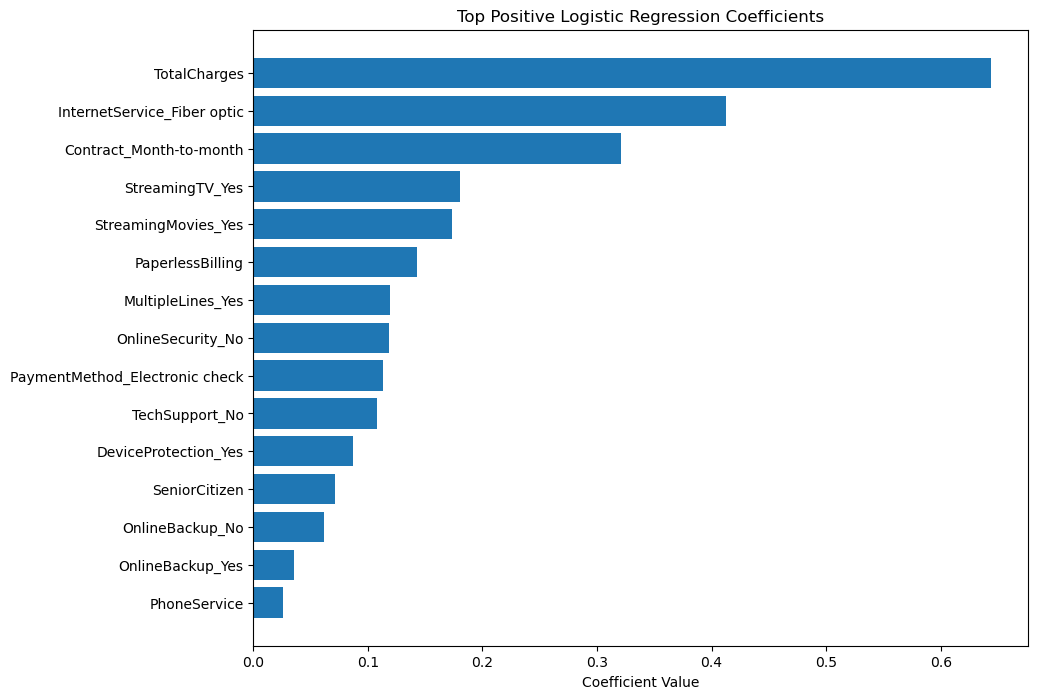

In [57]:
# Coefficients 

# Create coefficient dataframe

coef_df = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Coefficient': model.coef_[0]
})


# Sort coefficients

coef_df = coef_df.sort_values(
    by='Coefficient'
)


# Plot

plt.figure(figsize=(10,8))

plt.barh(
    coef_df['Feature'].tail(15),
    coef_df['Coefficient'].tail(15)
)

plt.title("Top Positive Logistic Regression Coefficients")

plt.xlabel("Coefficient Value")

plt.show()

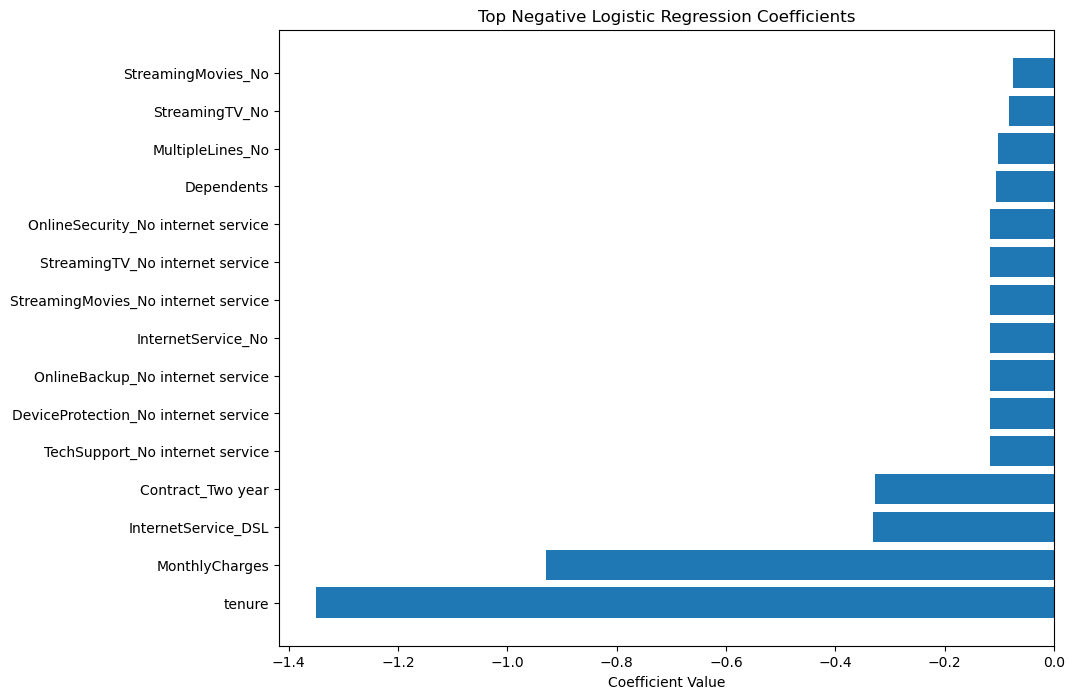

In [58]:
# negative coefficients

plt.figure(figsize=(10,8))

plt.barh(
    coef_df['Feature'].head(15),
    coef_df['Coefficient'].head(15)
)

plt.title("Top Negative Logistic Regression Coefficients")

plt.xlabel("Coefficient Value")

plt.show()

### XGBoosting
* find the best for XGBClassifier

In [142]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    cv=8,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_full, y_train_full)

print("Best parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test_full)

print("Accuracy:", accuracy_score(y_test_full, y_pred))

print(classification_report(y_test_full, y_pred))

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Accuracy: 0.7981520966595593
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [63]:
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd

TRAINING RESULTS

Accuracy: 0.8215111111111111

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4130
           1       0.71      0.56      0.62      1495

    accuracy                           0.82      5625
   macro avg       0.78      0.74      0.75      5625
weighted avg       0.81      0.82      0.81      5625

TESTING RESULTS

Accuracy: 0.7981520966595593

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC Score: 0.8391502865336931
Confusion Matrix:
[[922 111]
 [173 201]]


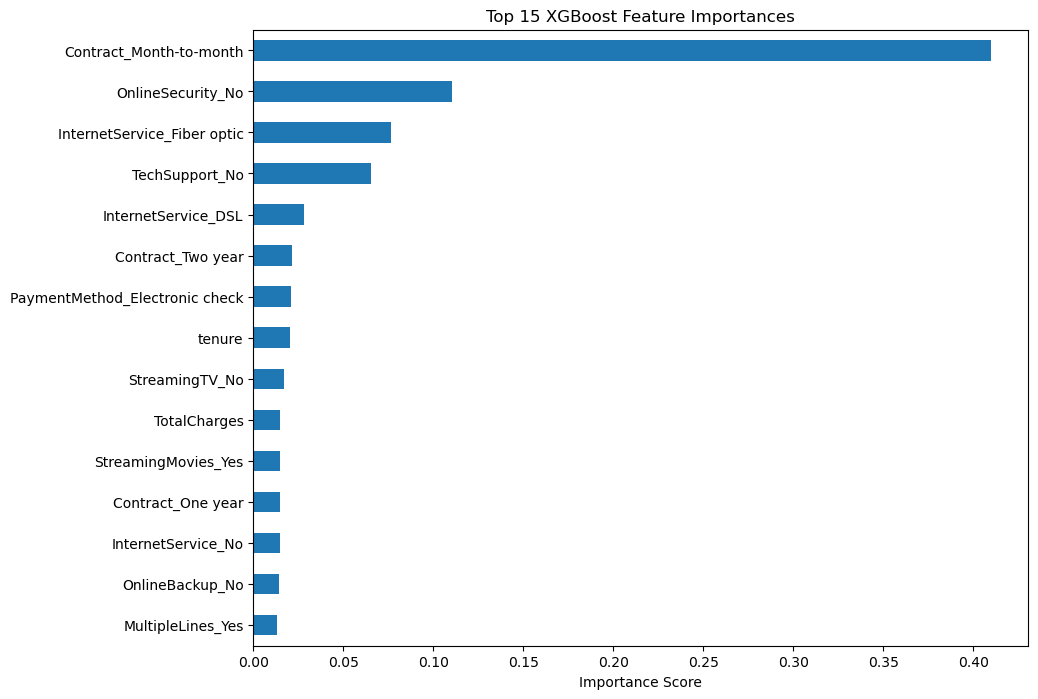

In [64]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=1,
    colsample_bytree=0.7,
    eval_metric='logloss'
)

xgb_model.fit(X_train_full, y_train_full)
y_train_pred = xgb_model.predict(X_train_full)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_full, y_train_pred))

print()

print(classification_report(
    y_train_full,
    y_train_pred
))

y_test_pred = xgb_model.predict(X_test_full)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_full, y_test_pred))

print()

print(classification_report(
    y_test_full,
    y_test_pred
))


y_test_prob = xgb_model.predict_proba(X_test_full)[:,1]

roc_auc = roc_auc_score(y_test_full, y_test_prob)

print("ROC-AUC Score:", roc_auc)

cm = confusion_matrix(y_test_full, y_test_pred)

print("Confusion Matrix:")
print(cm)

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_full.columns
).sort_values()

plt.figure(figsize=(10,8))

importance.tail(15).plot(kind='barh')

plt.title("Top 15 XGBoost Feature Importances")

plt.xlabel("Importance Score")

plt.show()



### ADABoosting

In [128]:
ada = AdaBoostClassifier(random_state=42)

# Hyperparameter grid
param_dist_ada = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.3, 1.0]
}

# Randomized Search
random_search_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist_ada,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit search
random_search_ada.fit(X_train_full, y_train_full)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,AdaBoostClass...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.03, ...], 'n_estimators': [50, 100, ...]}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


TRAINING RESULTS

Accuracy: 0.8067555555555556

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4130
           1       0.66      0.55      0.60      1495

    accuracy                           0.81      5625
   macro avg       0.76      0.73      0.74      5625
weighted avg       0.80      0.81      0.80      5625

TESTING RESULTS

Accuracy: 0.7931769722814499

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407

ROC-AUC Score: 0.8356960930988606
Confusion Matrix:
[[914 119]
 [172 202]]
Contract_Month-to-month                    0.258910
tenure                                     0.210553
MonthlyCharges                             0.147098
InternetService_Fibe

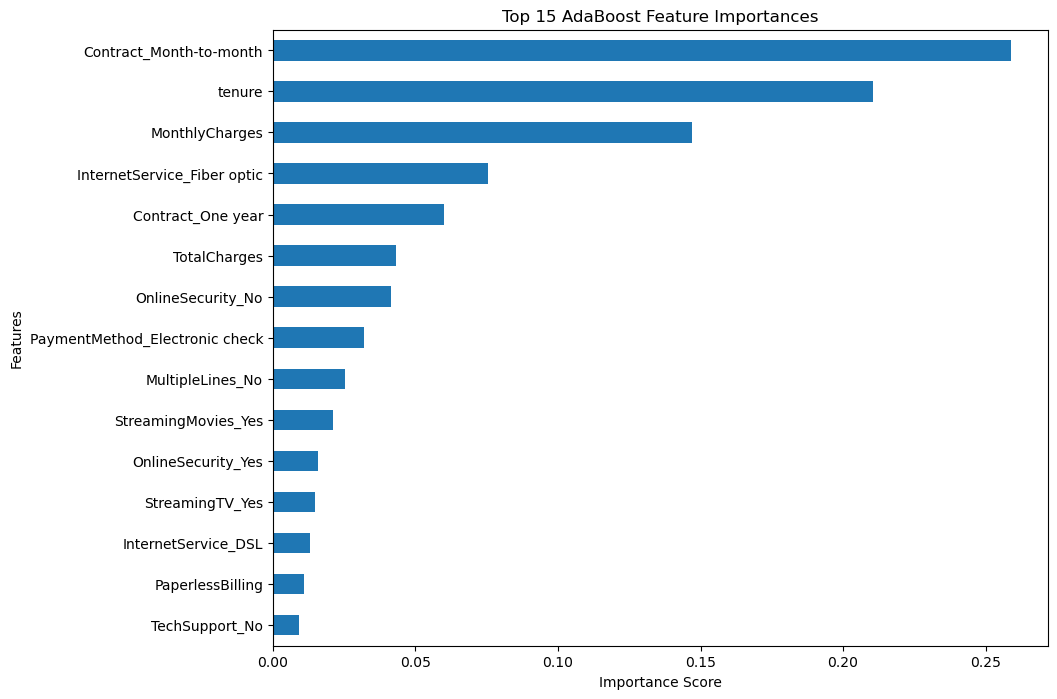

In [69]:
ada_model = AdaBoostClassifier(
    n_estimators= 200,
    learning_rate=1.0,
    random_state=42
)


# Train model

ada_model.fit(X_train_full, y_train_full)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = ada_model.predict(X_train_full)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_full, y_train_pred))

print()

print(classification_report(
    y_train_full,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = ada_model.predict(X_test_full)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_full, y_test_pred))

print()

print(classification_report(
    y_test_full,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = ada_model.predict_proba(X_test_full)[:,1]

roc_auc = roc_auc_score(y_test_full, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_full, y_test_pred)

print("Confusion Matrix:")
print(cm)


# =========================
# FEATURE IMPORTANCE
# =========================

importance_ada = pd.Series(
    ada_model.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)


# Print importance values

print(importance_ada)


# Plot top 15 features

plt.figure(figsize=(10,8))

importance_ada.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 AdaBoost Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

### Gradient Boosting

In [65]:
from sklearn.ensemble import GradientBoostingClassifier

In [129]:
# Gradient Boosting model
gb = GradientBoostingClassifier(random_state=42)

# Hyperparameter grid
param_dist_gb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

# Randomized Search
random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=40,
    cv=8,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit search
random_search_gb.fit(X_train_full, y_train_full)

# Best parameters
print("Best Gradient Boosting Parameters:")
print(random_search_gb.best_params_)

# Best model
best_gb = random_search_gb.best_estimator_

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best Gradient Boosting Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 3, 'learning_rate': 0.05}


TRAINING RESULTS

Accuracy: 0.8186666666666667

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4130
           1       0.70      0.56      0.62      1495

    accuracy                           0.82      5625
   macro avg       0.77      0.74      0.75      5625
weighted avg       0.81      0.82      0.81      5625

TESTING RESULTS

Accuracy: 0.7960199004975125

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC Score: 0.8390480455140782
Confusion Matrix:
[[921 112]
 [175 199]]
tenure                                     0.191163
TechSupport_No                             0.115179
Contract_Month-to-month                    0.092387
TotalCharges        

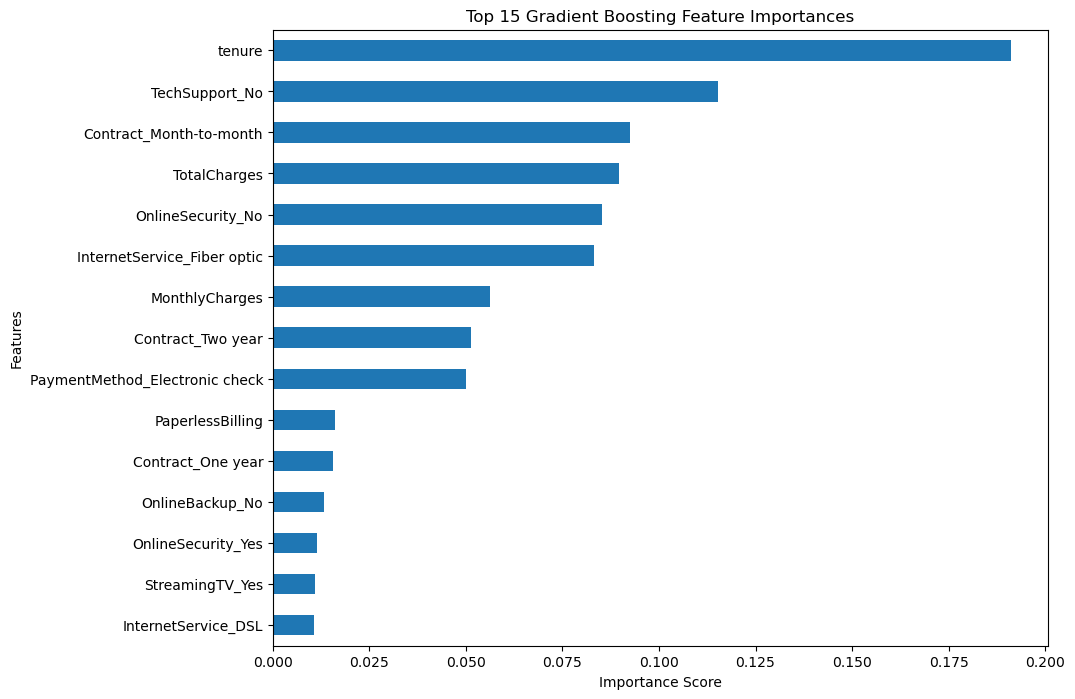

In [70]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=2,
    subsample=0.8,
    max_features='log2',
    random_state=42
)


# Train model

gb_model.fit(X_train_full, y_train_full)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = gb_model.predict(X_train_full)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_full, y_train_pred))

print()

print(classification_report(
    y_train_full,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = gb_model.predict(X_test_full)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_full, y_test_pred))

print()

print(classification_report(
    y_test_full,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = gb_model.predict_proba(X_test_full)[:,1]

roc_auc = roc_auc_score(y_test_full, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_full, y_test_pred)

print("Confusion Matrix:")
print(cm)


# =========================
# FEATURE IMPORTANCE
# =========================

importance_gb = pd.Series(
    gb_model.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)


# Print importance values

print(importance_gb)


# Plot top 15 features

plt.figure(figsize=(10,8))

importance_gb.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Gradient Boosting Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

### Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Randomized Search
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit search
random_search_rf.fit(X_train_full, y_train_full)

# Best parameters
print("Best Parameters:")
print(random_search_rf.best_params_)

# Best model
best_rf = random_search_rf.best_estimator_

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}


TRAINING RESULTS

Accuracy: 0.8563555555555555

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4130
           1       0.78      0.64      0.70      1495

    accuracy                           0.86      5625
   macro avg       0.83      0.79      0.80      5625
weighted avg       0.85      0.86      0.85      5625

TESTING RESULTS

Accuracy: 0.7953091684434968

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC Score: 0.8328462864508646
Confusion Matrix:
[[923 110]
 [178 196]]
tenure                                     0.143114
Contract_Month-to-month                    0.139657
TotalCharges                               0.111327
MonthlyCharges      

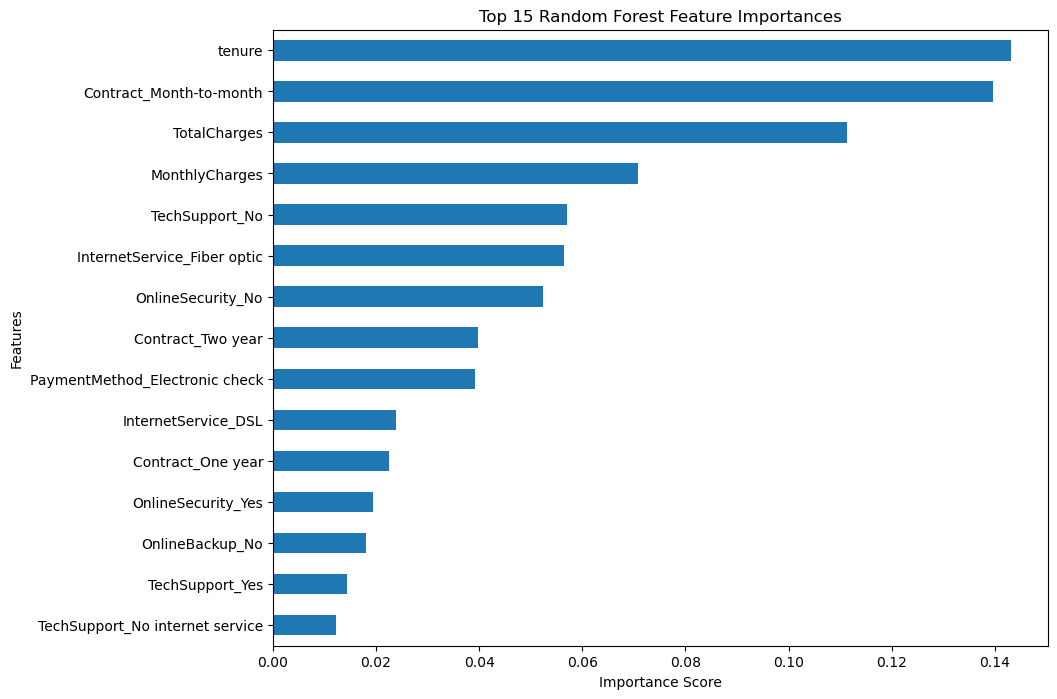

In [72]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='log2',
    max_depth=10,
    bootstrap=False,
    random_state=42
)


# Train model

rf_model.fit(X_train_full, y_train_full)


y_train_pred = rf_model.predict(X_train_full)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_full, y_train_pred))

print()

print(classification_report(
    y_train_full,
    y_train_pred
))

y_test_pred = rf_model.predict(X_test_full)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_full, y_test_pred))

print()

print(classification_report(
    y_test_full,
    y_test_pred
))

y_test_prob = rf_model.predict_proba(X_test_full)[:,1]

roc_auc = roc_auc_score(y_test_full, y_test_prob)

print("ROC-AUC Score:", roc_auc)

cm = confusion_matrix(y_test_full, y_test_pred)

print("Confusion Matrix:")
print(cm)


importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)


# Print feature importance values

print(importance_rf)


# Plot top 15 most important features

plt.figure(figsize=(10,8))

importance_rf.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Random Forest Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()


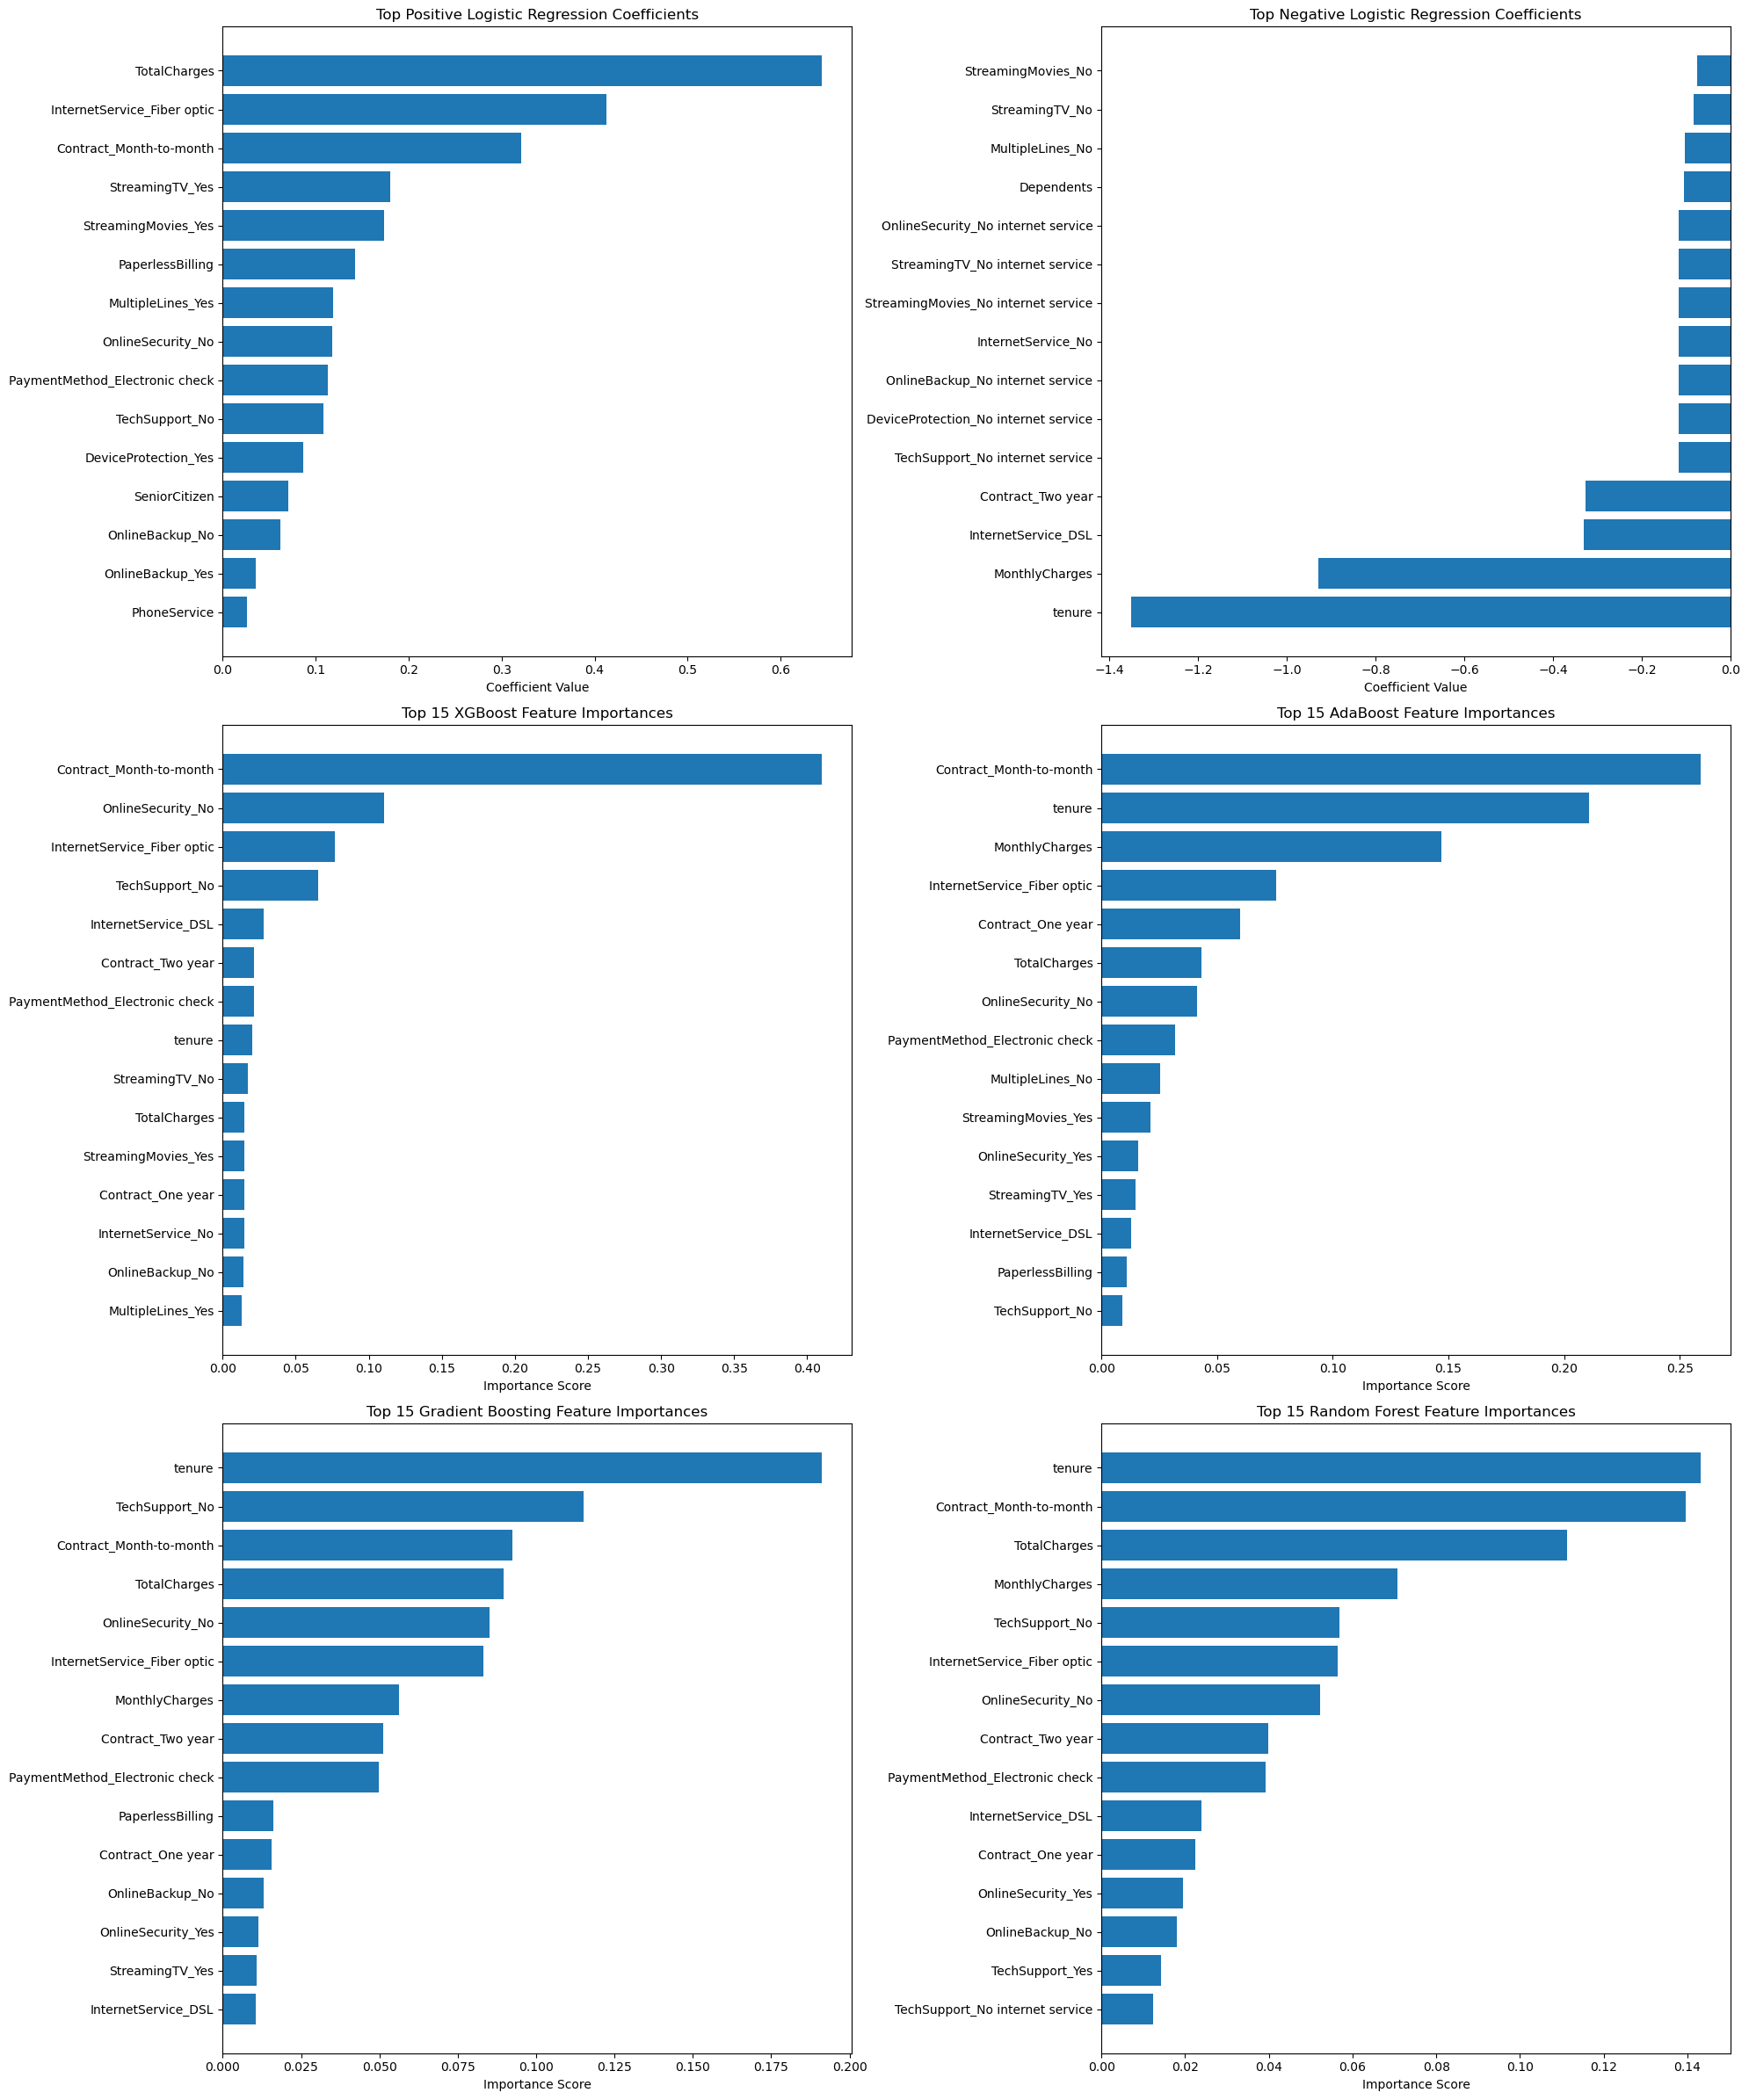

In [73]:
import matplotlib.pyplot as plt
import pandas as pd


# =========================
# LOGISTIC REGRESSION COEFFICIENTS
# =========================

coef_df = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient')


# =========================
# XGBOOST IMPORTANCE
# =========================

importance_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)


# =========================
# ADABOOST IMPORTANCE
# =========================

importance_ada = pd.Series(
    ada_model.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)


# =========================
# GRADIENT BOOSTING IMPORTANCE
# =========================

importance_gb = pd.Series(
    gb_model.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)


# =========================
# RANDOM FOREST IMPORTANCE
# =========================

importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train_full.columns
).sort_values(ascending=False)


# =========================
# CREATE SUBPLOTS
# =========================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(20,24)
)

axes = axes.flatten()


# =========================
# 1. POSITIVE LOGISTIC COEFFICIENTS
# =========================

axes[0].barh(
    coef_df['Feature'].tail(15),
    coef_df['Coefficient'].tail(15)
)

axes[0].set_title(
    "Top Positive Logistic Regression Coefficients"
)

axes[0].set_xlabel("Coefficient Value")


# =========================
# 2. NEGATIVE LOGISTIC COEFFICIENTS
# =========================

axes[1].barh(
    coef_df['Feature'].head(15),
    coef_df['Coefficient'].head(15)
)

axes[1].set_title(
    "Top Negative Logistic Regression Coefficients"
)

axes[1].set_xlabel("Coefficient Value")


# =========================
# 3. XGBOOST FEATURE IMPORTANCE
# =========================

axes[2].barh(
    importance_xgb.head(15).sort_values().index,
    importance_xgb.head(15).sort_values().values
)

axes[2].set_title(
    "Top 15 XGBoost Feature Importances"
)

axes[2].set_xlabel("Importance Score")


# =========================
# 4. ADABOOST FEATURE IMPORTANCE
# =========================

axes[3].barh(
    importance_ada.head(15).sort_values().index,
    importance_ada.head(15).sort_values().values
)

axes[3].set_title(
    "Top 15 AdaBoost Feature Importances"
)

axes[3].set_xlabel("Importance Score")


# =========================
# 5. GRADIENT BOOSTING FEATURE IMPORTANCE
# =========================

axes[4].barh(
    importance_gb.head(15).sort_values().index,
    importance_gb.head(15).sort_values().values
)

axes[4].set_title(
    "Top 15 Gradient Boosting Feature Importances"
)

axes[4].set_xlabel("Importance Score")


# =========================
# 6. RANDOM FOREST FEATURE IMPORTANCE
# =========================

axes[5].barh(
    importance_rf.head(15).sort_values().index,
    importance_rf.head(15).sort_values().values
)

axes[5].set_title(
    "Top 15 Random Forest Feature Importances"
)

axes[5].set_xlabel("Importance Score")


# =========================
# FINAL LAYOUT
# =========================

plt.tight_layout()

plt.show()

### df_drop

### Linear Regression
* this will be the wrong model to use 

In [46]:
X_drop = df_drop.drop('Churn', axis = 1)
y_drop = df_drop['Churn']

X_train_drop, X_test_drop, y_train_drop, y_test_drop = train_test_split(X_drop, y_drop, test_size = 0.2, random_state = 42, stratify = y_drop)

### KNN

In [148]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_drop)
X_test_scaled = scaler.transform(X_test_drop)


# =========================
# KNN MODEL
# =========================

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski'
)


# Train model

knn_model.fit(X_train_scaled, y_train_drop)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = knn_model.predict(X_train_scaled)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_drop, y_train_pred))

print()

print(classification_report(
    y_train_drop,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = knn_model.predict(X_test_scaled)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_drop, y_test_pred))

print()

print(classification_report(
    y_test_drop,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = knn_model.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test_drop, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_drop, y_test_pred)

print("Confusion Matrix:")
print(cm)

TRAINING RESULTS

Accuracy: 0.8350222222222222

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4130
           1       0.71      0.64      0.67      1495

    accuracy                           0.84      5625
   macro avg       0.79      0.77      0.78      5625
weighted avg       0.83      0.84      0.83      5625

TESTING RESULTS

Accuracy: 0.7540867093105899

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.54      0.54      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407

ROC-AUC Score: 0.7671544900632082
Confusion Matrix:
[[860 173]
 [173 201]]


### LogisticRegression

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_drop)

X_test_scaled = scaler.transform(X_test_drop)

# =========================
# LOGISTIC REGRESSION MODEL
# =========================

model = LogisticRegression(max_iter=1000)

# Train model

model.fit(X_train_scaled, y_train_drop)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = model.predict(X_train_scaled)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_drop, y_train_pred))

print()

print(classification_report(
    y_train_drop,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = model.predict(X_test_scaled)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_drop, y_test_pred))

print()

print(classification_report(
    y_test_drop,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = model.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test_drop, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_drop, y_test_pred)

print("Confusion Matrix:")
print(cm)



TRAINING RESULTS

Accuracy: 0.8042666666666667

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4130
           1       0.66      0.55      0.60      1495

    accuracy                           0.80      5625
   macro avg       0.75      0.72      0.73      5625
weighted avg       0.80      0.80      0.80      5625

TESTING RESULTS

Accuracy: 0.8038379530916845

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC Score: 0.8356727976766699
Confusion Matrix:
[[916 117]
 [159 215]]


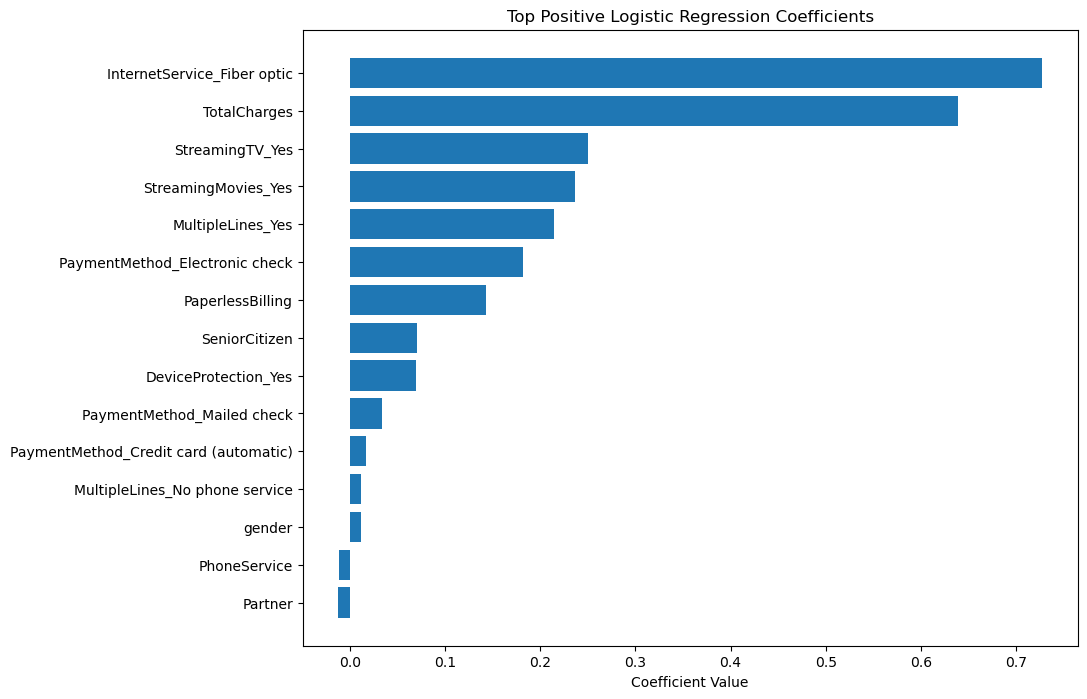

In [75]:
# Coefficients 

# Create coefficient dataframe

coef_df = pd.DataFrame({
    'Feature': X_train_drop.columns,
    'Coefficient': model.coef_[0]
})


# Sort coefficients

coef_df = coef_df.sort_values(
    by='Coefficient'
)


# Plot

plt.figure(figsize=(10,8))

plt.barh(
    coef_df['Feature'].tail(15),
    coef_df['Coefficient'].tail(15)
)

plt.title("Top Positive Logistic Regression Coefficients")

plt.xlabel("Coefficient Value")

plt.show()

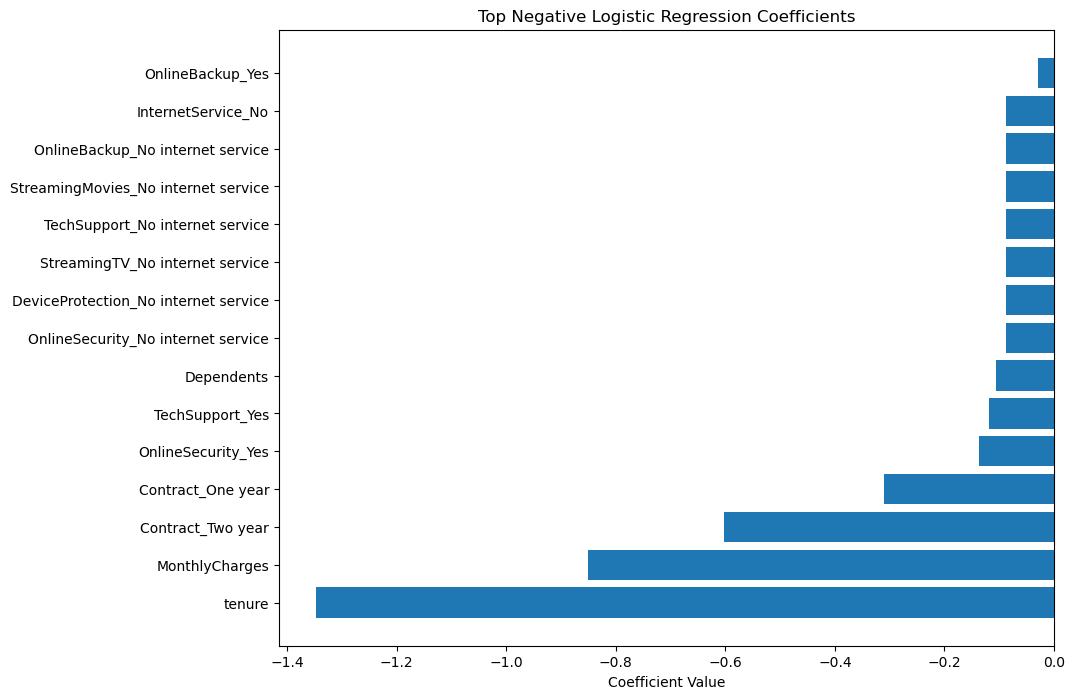

In [76]:
# negative coefficients

plt.figure(figsize=(10,8))

plt.barh(
    coef_df['Feature'].head(15),
    coef_df['Coefficient'].head(15)
)

plt.title("Top Negative Logistic Regression Coefficients")

plt.xlabel("Coefficient Value")

plt.show()

### XGBClassifier
* for the drop data

In [139]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    cv=8,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_drop, y_train_drop)

print("Best parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test_drop)

print("Accuracy:", accuracy_score(y_test_drop, y_pred))

print(classification_report(y_test_drop, y_pred))

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best parameters:
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Accuracy: 0.7917555081734187
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



TRAINING RESULTS

Accuracy: 0.8268444444444445

              precision    recall  f1-score   support

           0       0.85      0.92      0.89      4130
           1       0.72      0.57      0.64      1495

    accuracy                           0.83      5625
   macro avg       0.79      0.74      0.76      5625
weighted avg       0.82      0.83      0.82      5625

TESTING RESULTS

Accuracy: 0.7917555081734187

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC Score: 0.8378431545107703
Confusion Matrix:
[[915 118]
 [175 199]]


Text(0.5, 0, 'Importance Score')

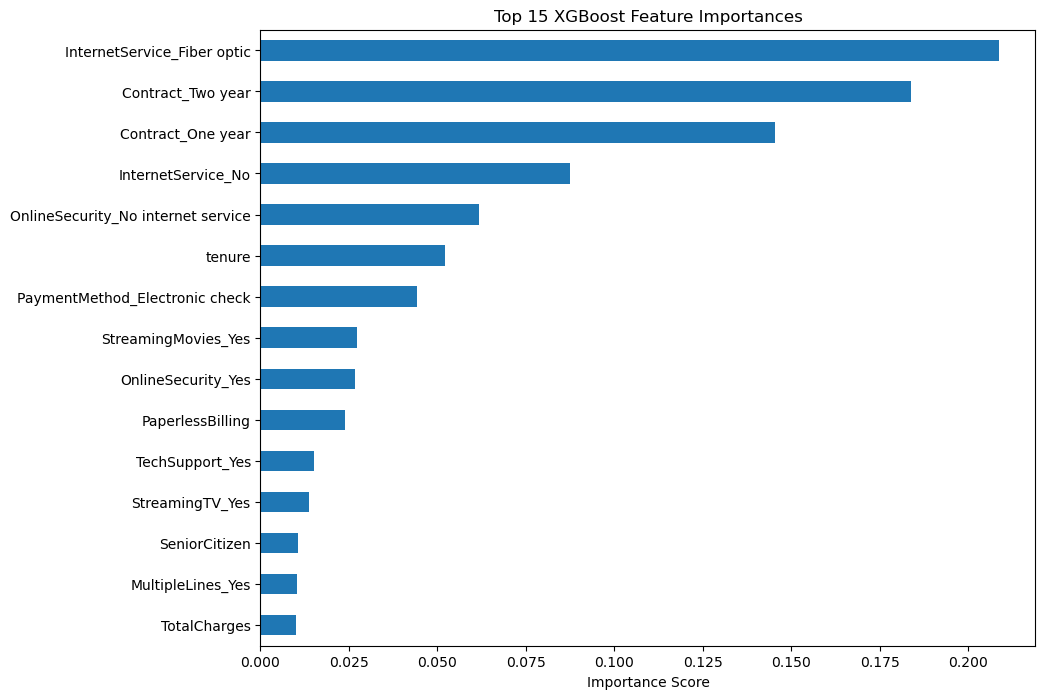

In [77]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=1,
    colsample_bytree=0.9,
    eval_metric='logloss'
)

xgb_model.fit(X_train_drop, y_train_drop)
y_train_pred = xgb_model.predict(X_train_drop)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_drop, y_train_pred))

print()

print(classification_report(
    y_train_drop,
    y_train_pred
))

y_test_pred = xgb_model.predict(X_test_drop)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_drop, y_test_pred))

print()

print(classification_report(
    y_test_drop,
    y_test_pred
))


y_test_prob = xgb_model.predict_proba(X_test_drop)[:,1]

roc_auc = roc_auc_score(y_test_drop, y_test_prob)

print("ROC-AUC Score:", roc_auc)

cm = confusion_matrix(y_test_drop, y_test_pred)

print("Confusion Matrix:")
print(cm)

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_drop.columns
).sort_values()

plt.figure(figsize=(10,8))

importance.tail(15).plot(kind='barh')

plt.title("Top 15 XGBoost Feature Importances")

plt.xlabel("Importance Score")


### ADABoosting

In [67]:
from sklearn.ensemble import AdaBoostClassifier

In [131]:
ada = AdaBoostClassifier(random_state=42)

# Hyperparameter grid
param_dist_ada = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.3, 1.0]
}

# Randomized Search
random_search_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist_ada,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit search
random_search_ada.fit(X_train_drop, y_train_drop)

# Best parameters
print("Best AdaBoost Parameters:")
print(random_search_ada.best_params_)

# Best model
best_ada = random_search_ada.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best AdaBoost Parameters:
{'n_estimators': 300, 'learning_rate': 1.0}


TRAINING RESULTS

Accuracy: 0.8078222222222222

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      4130
           1       0.68      0.53      0.59      1495

    accuracy                           0.81      5625
   macro avg       0.76      0.72      0.73      5625
weighted avg       0.80      0.81      0.80      5625

TESTING RESULTS

Accuracy: 0.7924662402274343

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8422343415937175
Confusion Matrix:
[[923 110]
 [182 192]]
tenure                                   0.350290
MonthlyCharges                           0.181755
Contract_Two year                        0.070150
PaymentMethod_Electronic c

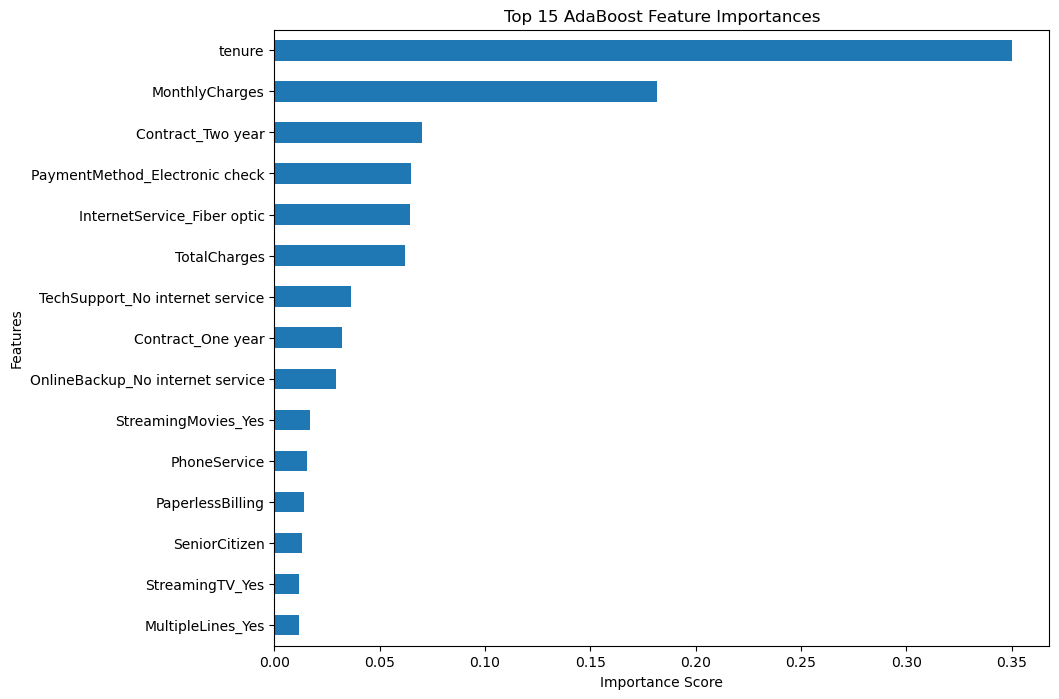

In [78]:
ada_model = AdaBoostClassifier(
    n_estimators= 300,
    learning_rate=1.0,
    random_state=42
)


# Train model

ada_model.fit(X_train_drop, y_train_drop)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = ada_model.predict(X_train_drop)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_drop, y_train_pred))

print()

print(classification_report(
    y_train_drop,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = ada_model.predict(X_test_drop)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_drop, y_test_pred))

print()

print(classification_report(
    y_test_drop,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = ada_model.predict_proba(X_test_drop)[:,1]

roc_auc = roc_auc_score(y_test_drop, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_drop, y_test_pred)

print("Confusion Matrix:")
print(cm)


# =========================
# FEATURE IMPORTANCE
# =========================

importance_ada = pd.Series(
    ada_model.feature_importances_,
    index=X_train_drop.columns
).sort_values(ascending=False)


# Print importance values

print(importance_ada)


# Plot top 15 features

plt.figure(figsize=(10,8))

importance_ada.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 AdaBoost Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

### Gradient Boosting

In [125]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [135]:
# Gradient Boosting model
gb = GradientBoostingClassifier(random_state=42)

# Hyperparameter grid
param_dist_gb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

# Randomized Search
random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=40,
    cv=8,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit search
random_search_gb.fit(X_train_drop, y_train_drop)

# Best parameters
print("Best Gradient Boosting Parameters:")
print(random_search_gb.best_params_)

# Best model
best_gb = random_search_gb.best_estimator_

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best Gradient Boosting Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 3, 'learning_rate': 0.05}


TRAINING RESULTS

Accuracy: 0.8174222222222223

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4130
           1       0.70      0.55      0.61      1495

    accuracy                           0.82      5625
   macro avg       0.77      0.73      0.75      5625
weighted avg       0.81      0.82      0.81      5625

TESTING RESULTS

Accuracy: 0.7938877043354655

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC Score: 0.8419327952953599
Confusion Matrix:
[[921 112]
 [178 196]]
tenure                                   0.175990
TotalCharges                             0.145427
InternetService_Fiber optic              0.116585
Contract_Two year         

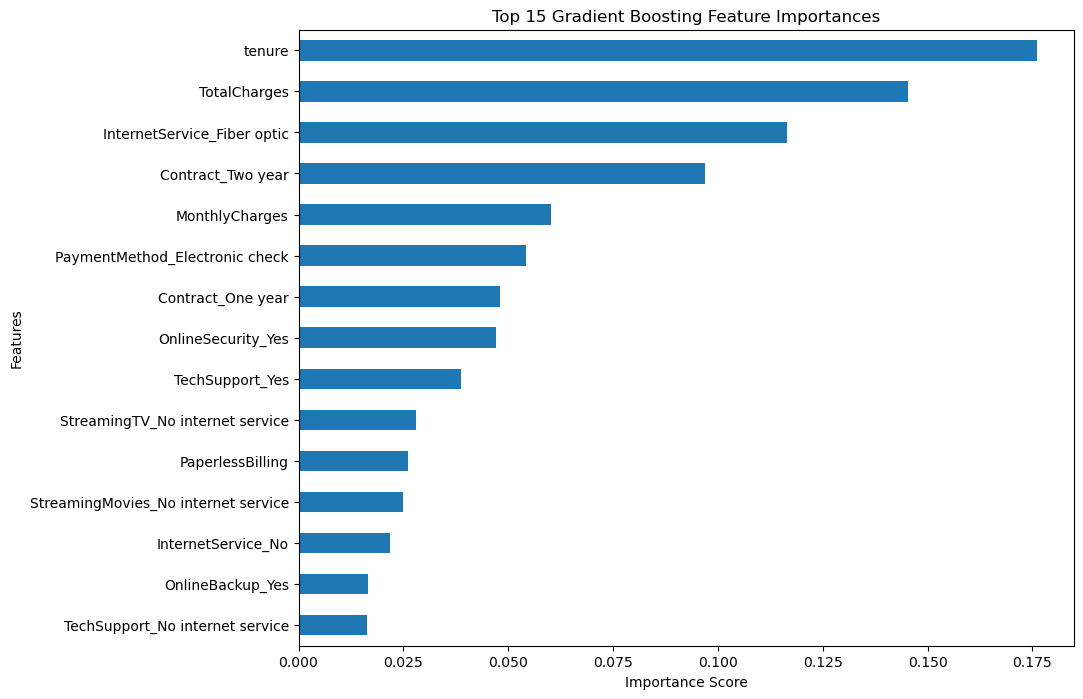

In [79]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=2,
    subsample=0.8,
    max_features='log2',
    random_state=42
)


# Train model

gb_model.fit(X_train_drop, y_train_drop)


# =========================
# TRAINING RESULTS
# =========================

y_train_pred = gb_model.predict(X_train_drop)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_drop, y_train_pred))

print()

print(classification_report(
    y_train_drop,
    y_train_pred
))


# =========================
# TESTING RESULTS
# =========================

y_test_pred = gb_model.predict(X_test_drop)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_drop, y_test_pred))

print()

print(classification_report(
    y_test_drop,
    y_test_pred
))


# =========================
# ROC-AUC SCORE
# =========================

y_test_prob = gb_model.predict_proba(X_test_drop)[:,1]

roc_auc = roc_auc_score(y_test_drop, y_test_prob)

print("ROC-AUC Score:", roc_auc)


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_drop, y_test_pred)

print("Confusion Matrix:")
print(cm)


# =========================
# FEATURE IMPORTANCE
# =========================

importance_gb = pd.Series(
    gb_model.feature_importances_,
    index=X_train_drop.columns
).sort_values(ascending=False)


# Print importance values

print(importance_gb)


# Plot top 15 features

plt.figure(figsize=(10,8))

importance_gb.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Gradient Boosting Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

### Random Forest

In [137]:
# Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Randomized Search
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit search
random_search_rf.fit(X_train_drop, y_train_drop)

# Best parameters
print("Best Parameters:")
print(random_search_rf.best_params_)

# Best model

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}


TRAINING RESULTS

Accuracy: 0.8663111111111111

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4130
           1       0.82      0.64      0.72      1495

    accuracy                           0.87      5625
   macro avg       0.85      0.79      0.82      5625
weighted avg       0.86      0.87      0.86      5625

TESTING RESULTS

Accuracy: 0.7903340440653873

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC Score: 0.8325512111031159
Confusion Matrix:
[[923 110]
 [185 189]]
tenure                                   0.195845
TotalCharges                             0.159985
MonthlyCharges                           0.119192
InternetService_Fiber opti

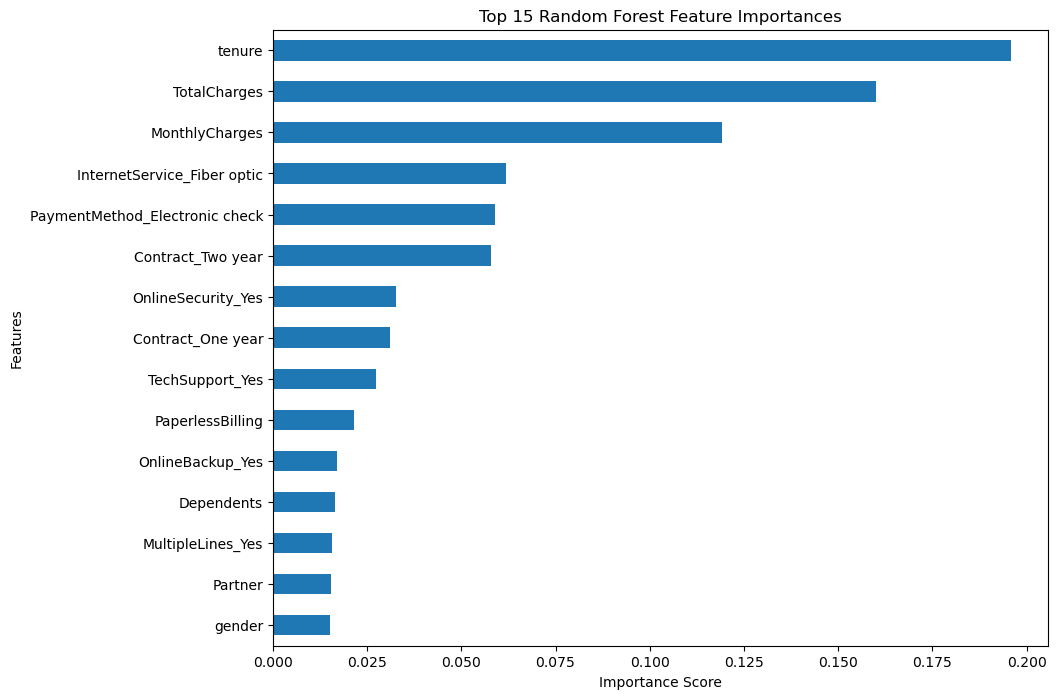

In [80]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=10,
    bootstrap=True,
    random_state=42
)


# Train model

rf_model.fit(X_train_drop, y_train_drop)


y_train_pred = rf_model.predict(X_train_drop)

print("TRAINING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_train_drop, y_train_pred))

print()

print(classification_report(
    y_train_drop,
    y_train_pred
))

y_test_pred = rf_model.predict(X_test_drop)

print("TESTING RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test_drop, y_test_pred))

print()

print(classification_report(
    y_test_drop,
    y_test_pred
))

y_test_prob = rf_model.predict_proba(X_test_drop)[:,1]

roc_auc = roc_auc_score(y_test_drop, y_test_prob)

print("ROC-AUC Score:", roc_auc)

cm = confusion_matrix(y_test_drop, y_test_pred)

print("Confusion Matrix:")
print(cm)


importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train_drop.columns
).sort_values(ascending=False)


# Print feature importance values

print(importance_rf)


# Plot top 15 most important features

plt.figure(figsize=(10,8))

importance_rf.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Random Forest Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

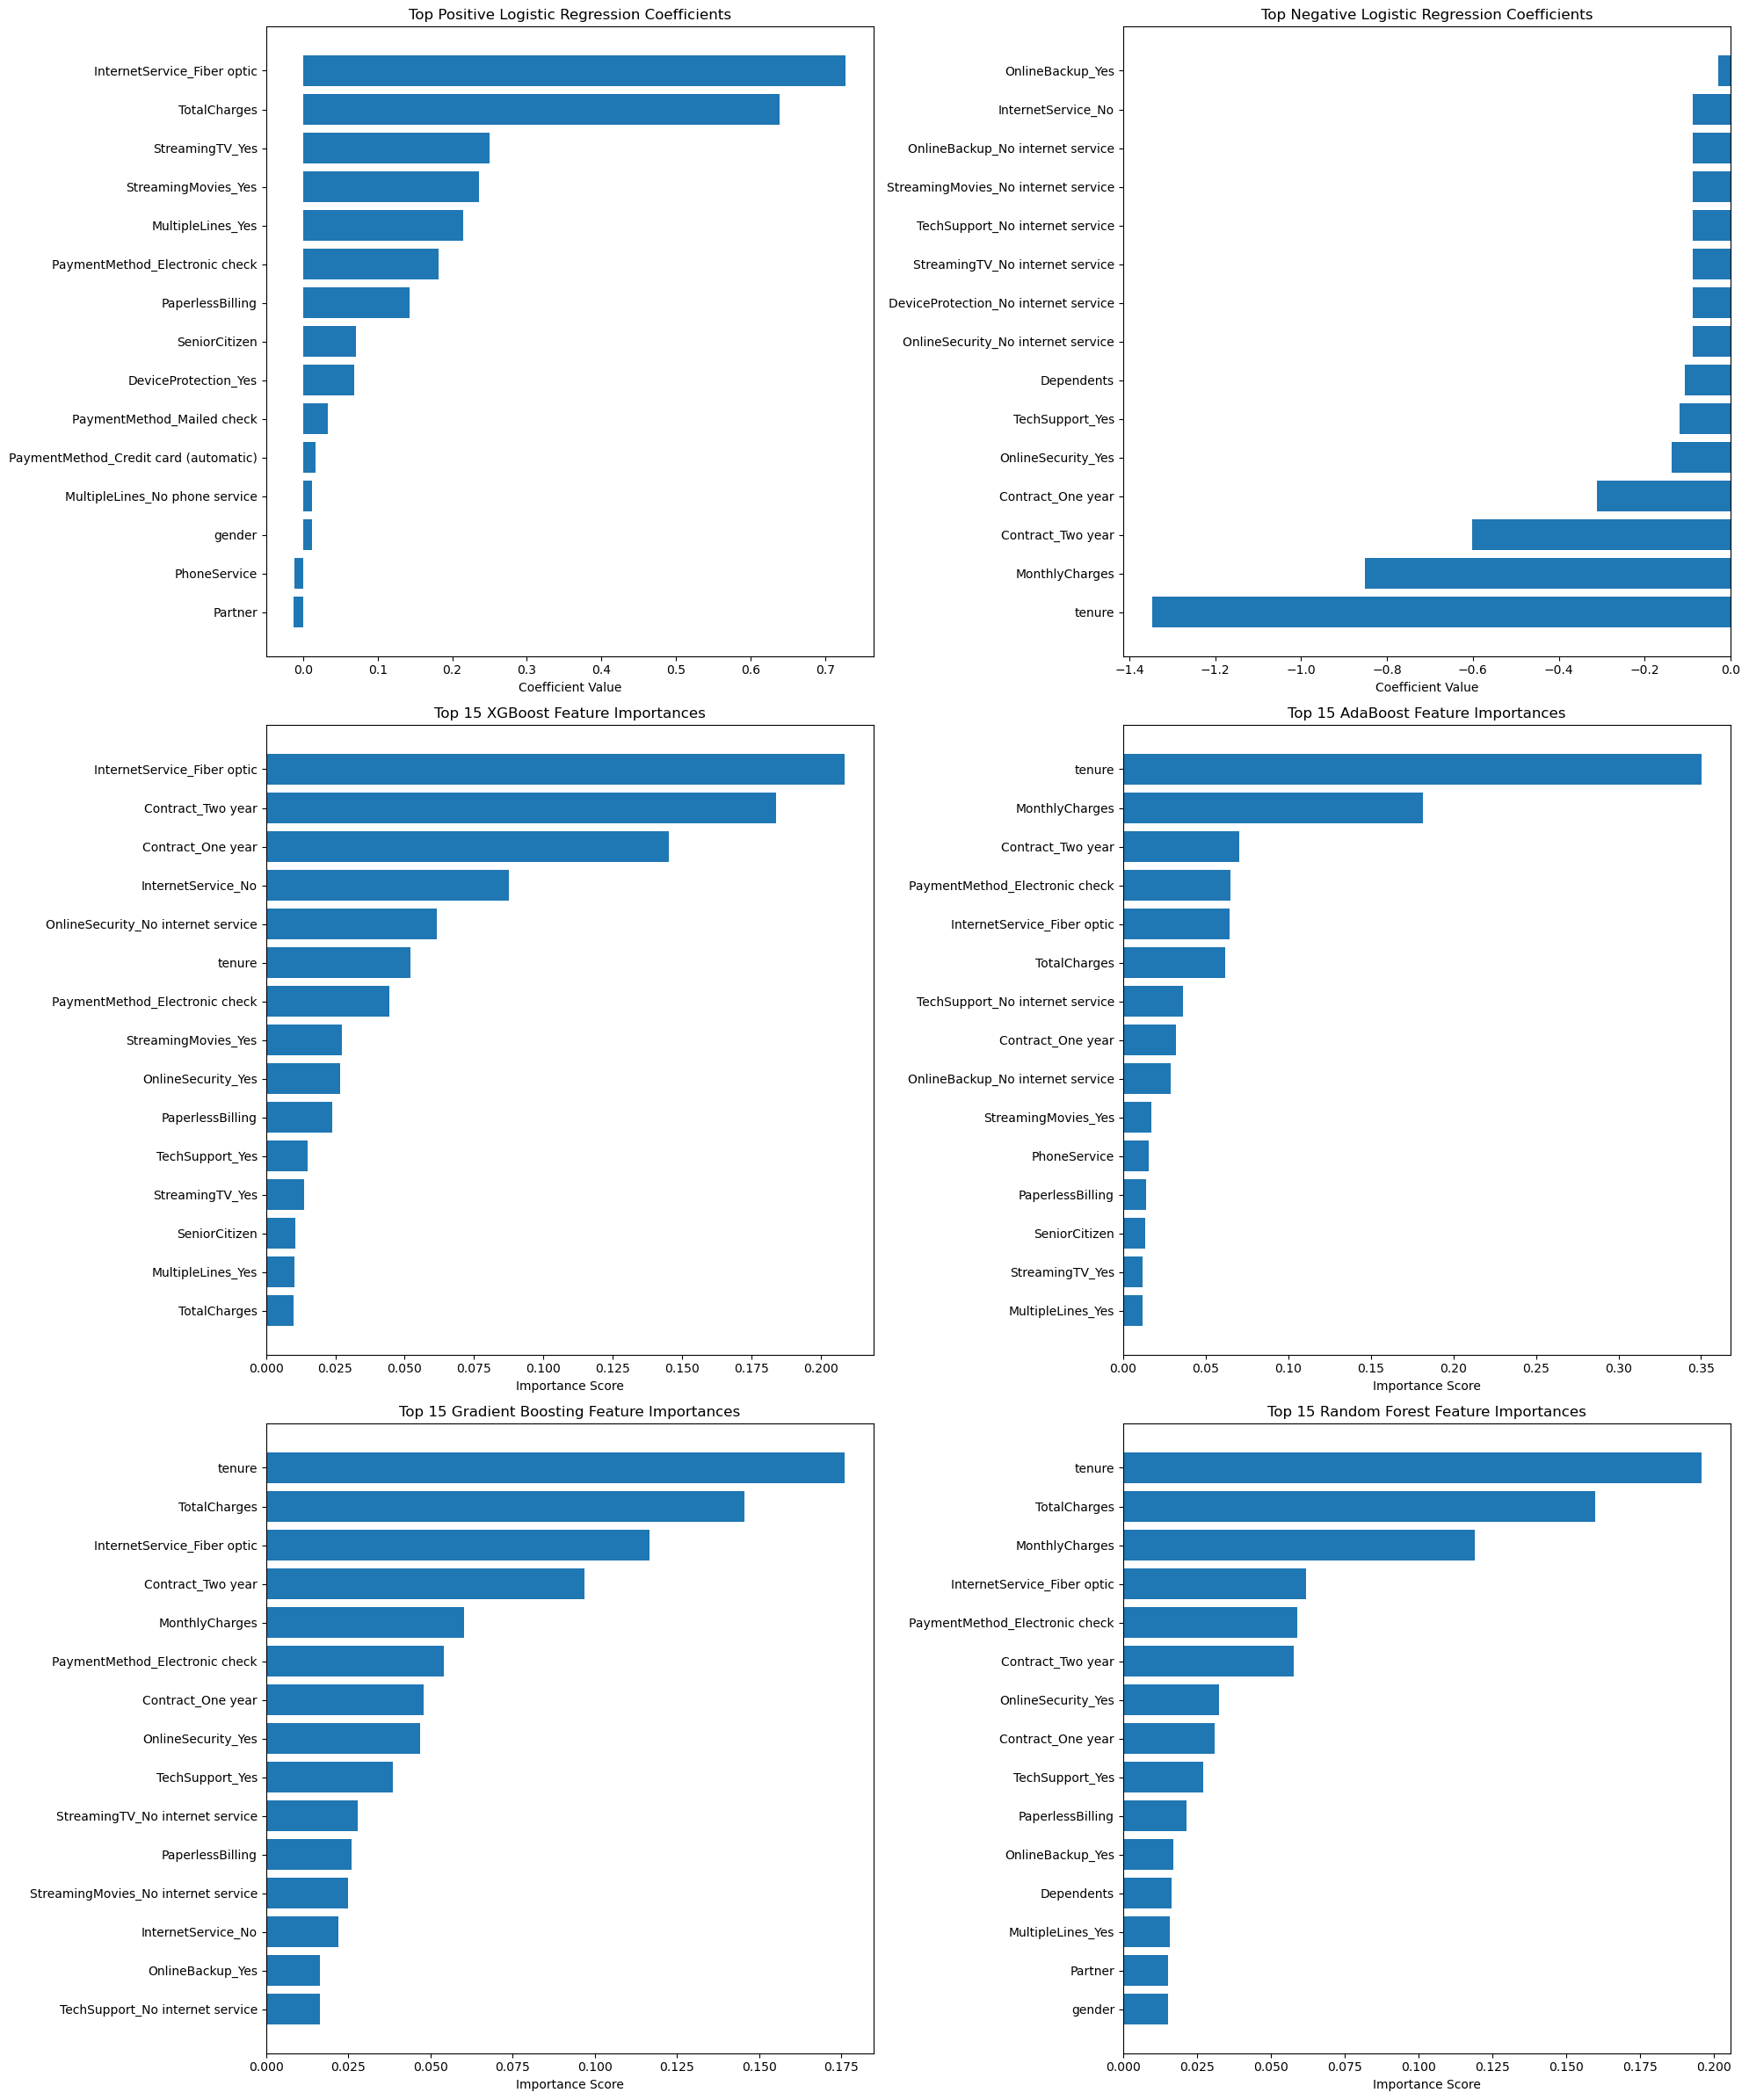

In [81]:
import matplotlib.pyplot as plt
import pandas as pd


# =========================
# LOGISTIC REGRESSION COEFFICIENTS
# =========================

coef_df = pd.DataFrame({
    'Feature': X_train_drop.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient')


# =========================
# XGBOOST IMPORTANCE
# =========================

importance_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_drop.columns
).sort_values(ascending=False)


# =========================
# ADABOOST IMPORTANCE
# =========================

importance_ada = pd.Series(
    ada_model.feature_importances_,
    index=X_train_drop.columns
).sort_values(ascending=False)


# =========================
# GRADIENT BOOSTING IMPORTANCE
# =========================

importance_gb = pd.Series(
    gb_model.feature_importances_,
    index=X_train_drop.columns
).sort_values(ascending=False)


# =========================
# RANDOM FOREST IMPORTANCE
# =========================

importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train_drop.columns
).sort_values(ascending=False)


# =========================
# CREATE SUBPLOTS
# =========================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(20,24)
)

axes = axes.flatten()


# =========================
# 1. POSITIVE LOGISTIC COEFFICIENTS
# =========================

axes[0].barh(
    coef_df['Feature'].tail(15),
    coef_df['Coefficient'].tail(15)
)

axes[0].set_title(
    "Top Positive Logistic Regression Coefficients"
)

axes[0].set_xlabel("Coefficient Value")


# =========================
# 2. NEGATIVE LOGISTIC COEFFICIENTS
# =========================

axes[1].barh(
    coef_df['Feature'].head(15),
    coef_df['Coefficient'].head(15)
)

axes[1].set_title(
    "Top Negative Logistic Regression Coefficients"
)

axes[1].set_xlabel("Coefficient Value")


# =========================
# 3. XGBOOST FEATURE IMPORTANCE
# =========================

axes[2].barh(
    importance_xgb.head(15).sort_values().index,
    importance_xgb.head(15).sort_values().values
)

axes[2].set_title(
    "Top 15 XGBoost Feature Importances"
)

axes[2].set_xlabel("Importance Score")


# =========================
# 4. ADABOOST FEATURE IMPORTANCE
# =========================

axes[3].barh(
    importance_ada.head(15).sort_values().index,
    importance_ada.head(15).sort_values().values
)

axes[3].set_title(
    "Top 15 AdaBoost Feature Importances"
)

axes[3].set_xlabel("Importance Score")


# =========================
# 5. GRADIENT BOOSTING FEATURE IMPORTANCE
# =========================

axes[4].barh(
    importance_gb.head(15).sort_values().index,
    importance_gb.head(15).sort_values().values
)

axes[4].set_title(
    "Top 15 Gradient Boosting Feature Importances"
)

axes[4].set_xlabel("Importance Score")


# =========================
# 6. RANDOM FOREST FEATURE IMPORTANCE
# =========================

axes[5].barh(
    importance_rf.head(15).sort_values().index,
    importance_rf.head(15).sort_values().values
)

axes[5].set_title(
    "Top 15 Random Forest Feature Importances"
)

axes[5].set_xlabel("Importance Score")


# =========================
# FINAL LAYOUT
# =========================

plt.tight_layout()

plt.show()

# Feature enginnering 


In [82]:
df_drop

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,0,0,1
7039,1,0,1,1,72,1,1,103.20,7362.90,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,0,0
7040,1,0,1,1,11,0,1,29.60,346.45,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [49]:
df_drop.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785,0.096701,0.421928,0.440273,0.216155,0.216155,0.286547,0.216155,0.344852,0.216155,0.343857,0.216155,0.290102,0.216155,0.384386,0.216155,0.388367,0.209329,0.239619,0.216297,0.336320,0.228100
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782,0.295571,0.493902,0.496455,0.411650,0.411650,0.452180,0.411650,0.475354,0.411650,0.475028,0.411650,0.453842,0.411650,0.486484,0.411650,0.487414,0.406858,0.426881,0.411748,0.472483,0.419637
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Total Service Count

In [83]:
service_cols = [
    'PhoneService',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

df_drop['TotalServices'] = (
    df_drop[service_cols]
    .sum(axis=1)
)

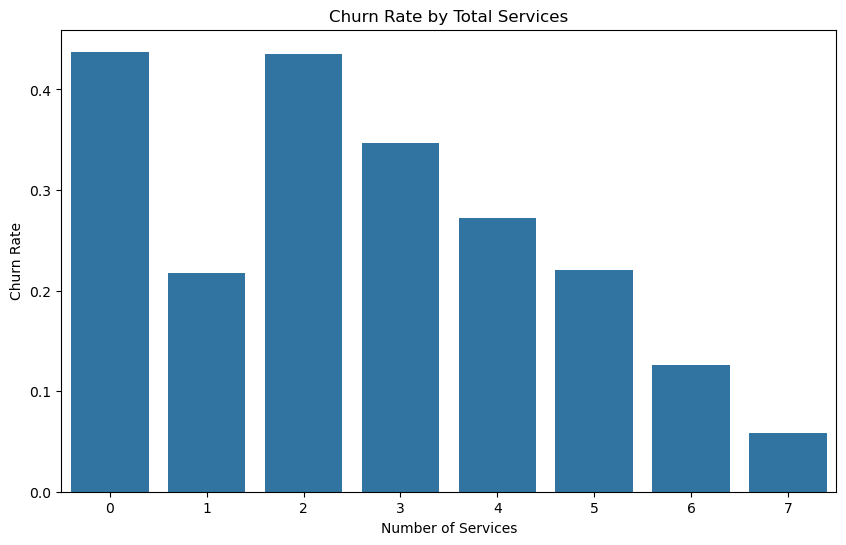

In [84]:
service_churn = df_drop.groupby(
    'TotalServices'
)['Churn'].mean()


# Plot

plt.figure(figsize=(10,6))

sns.barplot(
    x=service_churn.index,
    y=service_churn.values
)

plt.title("Churn Rate by Total Services")

plt.xlabel("Number of Services")

plt.ylabel("Churn Rate")

plt.show()

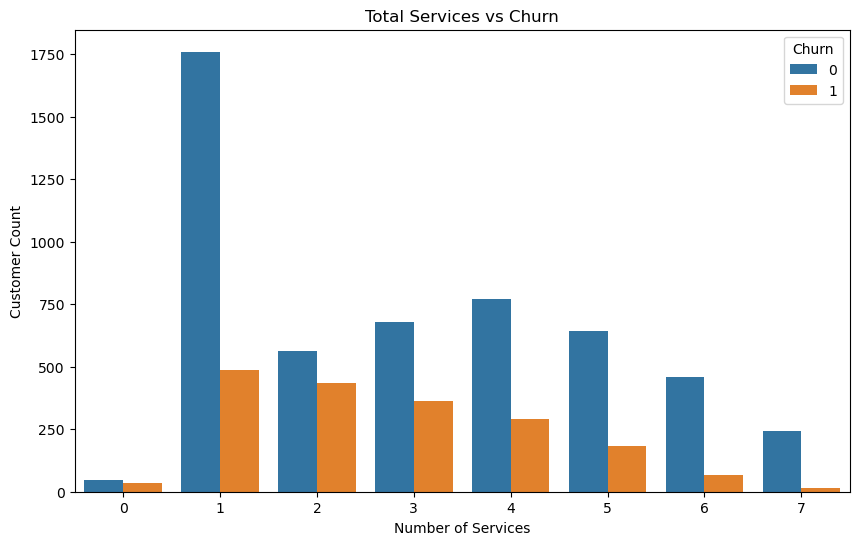

In [85]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='TotalServices',
    hue='Churn',
    data=df_drop
)

plt.title("Total Services vs Churn")

plt.xlabel("Number of Services")

plt.ylabel("Customer Count")

plt.show()



## Long Term Customer 

In [ ]:
df_drop['LongTermCustomer'] = (
    df_drop['tenure'] >= 29 
).astype(int)

## more than 50%